# Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

**MSc Artificial Intelligence — Bahrain Polytechnic**  
**Student: Jaafar Ahmed | ID: 202508989**

# Phase 7 — Model Explainability and Interpretation

This phase explains the finalist supervised models selected in Phase 6 without using the untouched holdout test set.

## Explainability safeguards

- The Phase 6 handoff is the authoritative source of finalist models.
- The Phase 3 training dataset is used for explanation and diagnostic validation only.
- The untouched holdout test set remains unopened until Phase 8.
- Cross-validated permutation importance is calculated on validation folds, not on the data used to fit each fold model.
- SHAP explanations are calculated from the finalist full-training models for mechanistic interpretation, not for estimating predictive performance.
- The target, identifiers, and `family_id` are never treated as predictors.
- Feature effects are model-response diagnostics and must not be interpreted as causal effects.

## Phase 7 Workflow

```text
Phase 6 finalist models
        ↓
Strict lineage and holdout verification
        ↓
Cross-validated permutation importance
        ↓
SHAP global and class-specific explanations
        ↓
Model-native importance and coefficient analysis
        ↓
Cross-model explainability consensus
        ↓
Local explanations for representative and difficult records
        ↓
Model-response feature effects
        ↓
Cluster-specific explanations
        ↓
Phase 8 handoff
```

# Section 7.1 — Load Phase 6 Handoff and Verify Data Lineage

In [1]:
# Cell 7.1.1 — Configure Environment, Project Folders, and Explainability Settings

from pathlib import Path
from datetime import datetime
from time import perf_counter
import copy
import hashlib
import importlib.util
import json
import math
import random
import re
import shutil
import subprocess
import sys
import warnings
import zipfile

# -----------------------------------------------------------------------------
# CHANGE THESE SETTINGS ONLY
# -----------------------------------------------------------------------------
EXECUTION_ENVIRONMENT = "COLAB"  # "COLAB", "ANACONDA", or "VSCODE"

PHASE_6_MANIFEST_OVERRIDE = None
PHASE_3_MANIFEST_OVERRIDE = None
PHASE_4_MANIFEST_OVERRIDE = None

PERMUTATION_REPEATS = 2
MAX_SHAP_SAMPLE = 160
MODEL_AGNOSTIC_SHAP_SAMPLE = 24
SHAP_BACKGROUND_SIZE = 16
SHAP_MONTE_CARLO_PERMUTATIONS = 12
FEATURE_EFFECT_SAMPLE_SIZE = 500
TOP_FEATURES_TO_REPORT = 12
TOP_FEATURES_FOR_EFFECTS = 5
LOCAL_CORRECT_EXAMPLES_PER_CLASS = 1
LOCAL_ERROR_EXAMPLES = 3
AUTO_INSTALL_MISSING_PACKAGES = True
# -----------------------------------------------------------------------------

PROJECT_TITLE = (
    "Design a Machine Learning Approach to Analyse Students’ Performance "
    "Based on Their Socio-economic Status in the Kingdom of Bahrain"
)
PROGRAMME = "MSc Artificial Intelligence — Bahrain Polytechnic"
STUDENT_NAME = "Jaafar Ahmed"
STUDENT_ID = "202508989"
RANDOM_STATE = 42

random.seed(RANDOM_STATE)

EXECUTION_ENVIRONMENT = EXECUTION_ENVIRONMENT.strip().upper()
if EXECUTION_ENVIRONMENT not in {"COLAB", "ANACONDA", "VSCODE"}:
    raise ValueError("Invalid execution environment.")

if EXECUTION_ENVIRONMENT == "COLAB":
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_ROOT = Path("/content/drive/MyDrive/Jaafar_MSc_Thesis")
    except ImportError:
        PROJECT_ROOT = Path.cwd()
        print("Google Colab is unavailable; using:", PROJECT_ROOT)
else:
    PROJECT_ROOT = Path.cwd()

SOURCE_DATA_DIR = PROJECT_ROOT / "data"
SOURCE_OUTPUT_ROOT = PROJECT_ROOT / "outputs"
PHASE_3_DIR = SOURCE_OUTPUT_ROOT / "Phase_03_Train_Test_Split_and_Preprocessing_Pipelines"
PHASE_4_DIR = SOURCE_OUTPUT_ROOT / "Phase_04_Supervised_Learning_Algorithms"
PHASE_6_DIR = SOURCE_OUTPUT_ROOT / "Phase_06_Model_Comparison_and_Quality_Checking"

DATA_DIR = SOURCE_DATA_DIR
OUTPUT_ROOT = SOURCE_OUTPUT_ROOT
PHASE_DIR = OUTPUT_ROOT / "Phase_07_Model_Explainability_and_Interpretation"
MODEL_DIR = PHASE_DIR / "explainability_artifacts"


def ensure_writable_folder(folder):
    folder.mkdir(parents=True, exist_ok=True)
    test_file = folder / ".phase_07_write_test"
    test_file.write_text("test", encoding="utf-8")
    test_file.unlink()


try:
    for folder in [DATA_DIR, OUTPUT_ROOT, PHASE_DIR, MODEL_DIR]:
        ensure_writable_folder(folder)
except (PermissionError, OSError):
    print(
        "The standard output folders are not writable in this runtime. "
        "Using portable Phase 7 folders instead."
    )
    DATA_DIR = PROJECT_ROOT / "phase_07_data"
    OUTPUT_ROOT = PROJECT_ROOT / "phase_07_outputs"
    PHASE_DIR = OUTPUT_ROOT / "Phase_07_Model_Explainability_and_Interpretation"
    MODEL_DIR = PHASE_DIR / "explainability_artifacts"
    for folder in [DATA_DIR, OUTPUT_ROOT, PHASE_DIR, MODEL_DIR]:
        ensure_writable_folder(folder)

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")


def safe_name(text):
    text = str(text).strip().replace("—", "-").replace("–", "-")
    text = re.sub(r"[^\w\-]+", "_", text, flags=re.UNICODE)
    return re.sub(r"_+", "_", text).strip("_") or "Unnamed"


def create_cell_folders(section_number, section_title, cell_number, cell_title):
    base = (
        PHASE_DIR
        / safe_name(f"Section_{section_number}_{section_title}")
        / safe_name(f"Cell_{cell_number}_{cell_title}")
    )
    folders = {
        "tables": base / "tables",
        "figures": base / "figures",
        "reports": base / "reports",
        "models": base / "models",
        "files": base / "files",
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders


def save_dataframe(dataframe, folders, file_stem, index=False):
    path = folders["tables"] / f"{file_stem}.csv"
    dataframe.to_csv(path, index=index, encoding="utf-8-sig")
    return path


def save_json_report(data, folders, file_stem):
    path = folders["reports"] / f"{file_stem}.json"
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2, default=str)
    return path


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def load_table(path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        try:
            return pd.read_csv(path, encoding="utf-8-sig")
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="latin-1")
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported input format: {path.suffix}")


CELL_FOLDERS = create_cell_folders(
    "07_01", "Load_Phase_6_Handoff_and_Verify_Data_Lineage",
    "07_01_01", "Configure_Environment_Project_Folders_and_Explainability_Settings"
)

project_configuration = {
    "project_title": PROJECT_TITLE,
    "programme": PROGRAMME,
    "student_name": STUDENT_NAME,
    "student_id": STUDENT_ID,
    "execution_environment": EXECUTION_ENVIRONMENT,
    "project_root": str(PROJECT_ROOT),
    "phase_7_directory": str(PHASE_DIR),
    "permutation_repeats": PERMUTATION_REPEATS,
    "max_shap_sample": MAX_SHAP_SAMPLE,
    "model_agnostic_shap_sample": MODEL_AGNOSTIC_SHAP_SAMPLE,
    "shap_background_size": SHAP_BACKGROUND_SIZE,
    "shap_monte_carlo_permutations": SHAP_MONTE_CARLO_PERMUTATIONS,
    "feature_effect_sample_size": FEATURE_EFFECT_SAMPLE_SIZE,
    "random_state": RANDOM_STATE,
    "run_timestamp": RUN_TIMESTAMP,
}

save_json_report(project_configuration, CELL_FOLDERS, "07_01_01_project_configuration")
print("Project root:", PROJECT_ROOT)
print("Phase 7 directory:", PHASE_DIR)

Google Colab is unavailable; using: C:\Users\User\Desktop\All
Project root: C:\Users\User\Desktop\All
Phase 7 directory: C:\Users\User\Desktop\All\outputs\Phase_07_Model_Explainability_and_Interpretation


In [2]:
# Cell 7.1.2 — Install and Import Required Libraries

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "shap": "shap",
    "catboost": "catboost",
}

installation_rows = []
for import_name, package_name in required_packages.items():
    present = importlib.util.find_spec(import_name) is not None
    if present:
        status = "Already installed"
    elif AUTO_INSTALL_MISSING_PACKAGES:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        status = "Installed during this run"
    else:
        raise ImportError(f"Missing package: {package_name}")
    installation_rows.append(
        {"import_name": import_name, "package_name": package_name, "status": status}
    )

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import scipy
import shap
import sklearn

from sklearn.base import clone
from sklearn.metrics import f1_score
from sklearn.model_selection import PredefinedSplit, train_test_split

warnings.filterwarnings("default")
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 180)
pd.set_option("display.width", 220)

THEME = {
    "maroon": "#6B1E32", "deep_maroon": "#43101F", "gold": "#D4A64A",
    "teal": "#237A7A", "coral": "#D96850", "indigo": "#525B92",
    "sage": "#7A9B76", "sand": "#D9C7A3", "warm_white": "#F7F4EF",
    "charcoal": "#2E3035", "soft_grey": "#D8D5D0", "blue": "#3F6F8F",
}

MODEL_COLORS = {
    "Dummy Baseline": "#999999",
    "Logistic Regression": THEME["maroon"],
    "K-Nearest Neighbours": THEME["gold"],
    "Support Vector Machine": THEME["indigo"],
    "Decision Tree": THEME["coral"],
    "Random Forest": THEME["teal"],
    "Gradient Boosting": THEME["sage"],
    "XGBoost": "#965D41",
    "CatBoost": "#7A4E9D",
    "Multi-Layer Perceptron": THEME["blue"],
}
MODEL_FALLBACK_COLORS = list(MODEL_COLORS.values()) + ["#8A6D3B", "#4C956C"]


def get_model_color(model_name):
    if model_name in MODEL_COLORS:
        return MODEL_COLORS[model_name]
    index = sum(ord(character) for character in str(model_name)) % len(MODEL_FALLBACK_COLORS)
    return MODEL_FALLBACK_COLORS[index]


mpl.rcParams.update({
    "figure.facecolor": THEME["warm_white"],
    "axes.facecolor": THEME["warm_white"],
    "savefig.facecolor": THEME["warm_white"],
    "text.color": THEME["charcoal"],
    "axes.labelcolor": THEME["charcoal"],
    "xtick.color": THEME["charcoal"],
    "ytick.color": THEME["charcoal"],
    "font.size": 10,
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "legend.frameon": False,
})


def style_axis(axis, title, subtitle=None, grid_axis="y"):
    axis.set_title(title, loc="left", pad=18, fontweight="bold")
    if subtitle:
        axis.text(0, 1.015, subtitle, transform=axis.transAxes, fontsize=9,
                  color="#5B5B5B", va="bottom")
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_alpha(0.35)
    axis.spines["bottom"].set_alpha(0.35)
    if grid_axis:
        axis.grid(axis=grid_axis, alpha=0.16)
    axis.set_axisbelow(True)


def save_figure(figure, folders, file_stem):
    path = folders["figures"] / f"{file_stem}.png"
    figure.text(
        0.01, 0.01,
        "MSc Artificial Intelligence — Bahrain Polytechnic | Phase 7",
        fontsize=7.5, color="#666666"
    )
    figure.savefig(path, dpi=300, bbox_inches="tight")
    return path


CELL_FOLDERS = create_cell_folders(
    "07_01", "Load_Phase_6_Handoff_and_Verify_Data_Lineage",
    "07_01_02", "Install_and_Import_Required_Libraries"
)

installation_report = pd.DataFrame(installation_rows)
library_versions = pd.DataFrame([
    ["Python", sys.version.split()[0]],
    ["pandas", pd.__version__],
    ["numpy", np.__version__],
    ["scipy", scipy.__version__],
    ["matplotlib", mpl.__version__],
    ["scikit-learn", sklearn.__version__],
    ["SHAP", shap.__version__],
    ["joblib", joblib.__version__],
], columns=["library", "version"])

save_dataframe(installation_report, CELL_FOLDERS, "07_01_02_installation_report")
save_dataframe(library_versions, CELL_FOLDERS, "07_01_02_library_versions")
display(library_versions)

,library,version
0,Python,3.13.5
1,pandas,2.2.3
2,numpy,2.1.3
3,scipy,1.15.3
4,matplotlib,3.10.0
5,scikit-learn,1.6.1
6,SHAP,0.51.0
7,joblib,1.4.2


In [3]:
# Cell 7.1.3 — Load Authoritative Manifests and Verify the Phase Chain

CELL_FOLDERS = create_cell_folders(
    "07_01", "Load_Phase_6_Handoff_and_Verify_Data_Lineage",
    "07_01_03", "Load_Authoritative_Manifests_and_Verify_the_Phase_Chain"
)


def first_existing(candidates, description):
    for candidate in candidates:
        if candidate is None:
            continue
        path = Path(candidate).expanduser()
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not locate {description}.")


PHASE_6_MANIFEST_PATH = first_existing([
    PHASE_6_MANIFEST_OVERRIDE,
    PHASE_6_DIR / "phase_06_handoff_manifest_for_phase_07.json",
    PROJECT_ROOT / "phase_06_handoff_manifest_for_phase_07.json",
    Path.cwd() / "phase_06_handoff_manifest_for_phase_07.json",
], "Phase 6 handoff manifest")

PHASE_3_MANIFEST_PATH = first_existing([
    PHASE_3_MANIFEST_OVERRIDE,
    PHASE_3_DIR / "phase_03_handoff_manifest_for_phase_04.json",
    PROJECT_ROOT / "phase_03_handoff_manifest_for_phase_04.json",
    Path.cwd() / "phase_03_handoff_manifest_for_phase_04.json",
], "Phase 3 handoff manifest")

PHASE_4_MANIFEST_PATH = first_existing([
    PHASE_4_MANIFEST_OVERRIDE,
    PHASE_4_DIR / "phase_04_handoff_manifest_for_phase_06.json",
    PROJECT_ROOT / "phase_04_handoff_manifest_for_phase_06.json",
    Path.cwd() / "phase_04_handoff_manifest_for_phase_06.json",
], "Phase 4 handoff manifest")

with PHASE_6_MANIFEST_PATH.open("r", encoding="utf-8") as file:
    phase_6_manifest = json.load(file)
with PHASE_3_MANIFEST_PATH.open("r", encoding="utf-8") as file:
    phase_3_manifest = json.load(file)
with PHASE_4_MANIFEST_PATH.open("r", encoding="utf-8") as file:
    phase_4_manifest = json.load(file)

if phase_6_manifest.get("holdout_test_used", False):
    raise AssertionError("Phase 6 reports that the holdout test was used.")
if phase_3_manifest.get("family_overlap", 0) != 0:
    raise AssertionError("Phase 3 reports family overlap between train and holdout.")

TRAINING_DATA_PATH = first_existing([
    phase_6_manifest.get("training_dataset"),
    phase_3_manifest.get("primary_training_dataset_for_phase_4"),
    SOURCE_DATA_DIR / "phase_03_training_dataset_for_phase_04.csv",
], "Phase 3 training dataset")

CV_ASSIGNMENT_PATH = first_existing([
    phase_6_manifest.get("cv_assignment"),
    phase_3_manifest.get("cross_validation_fold_assignment"),
    SOURCE_DATA_DIR / "phase_03_cross_validation_folds.csv",
], "Phase 3 cross-validation assignment")

OOF_PREDICTIONS_PATH = first_existing([
    phase_4_manifest.get("oof_predictions"),
    SOURCE_DATA_DIR / "phase_04_all_oof_predictions.csv",
], "Phase 4 out-of-fold predictions")

CLUSTER_ASSIGNMENTS_PATH = None
cluster_candidate = phase_6_manifest.get("phase_5_cluster_assignments")
if cluster_candidate and Path(cluster_candidate).exists():
    CLUSTER_ASSIGNMENTS_PATH = Path(cluster_candidate)
elif (SOURCE_DATA_DIR / "phase_05_cluster_assignments.csv").exists():
    CLUSTER_ASSIGNMENTS_PATH = SOURCE_DATA_DIR / "phase_05_cluster_assignments.csv"

training_data = load_table(TRAINING_DATA_PATH)
cv_assignment = load_table(CV_ASSIGNMENT_PATH)
oof_predictions = load_table(OOF_PREDICTIONS_PATH)
cluster_assignments = (
    load_table(CLUSTER_ASSIGNMENTS_PATH)
    if CLUSTER_ASSIGNMENTS_PATH is not None
    else pd.DataFrame()
)

expected_records = phase_3_manifest.get("training_records")
expected_hash = phase_3_manifest.get("training_dataset_sha256")
observed_hash = sha256_file(TRAINING_DATA_PATH)

lineage_checks = pd.DataFrame([
    ["Phase 6 holdout_test_used is False", not phase_6_manifest.get("holdout_test_used", False), False],
    ["Training record count matches Phase 3 manifest",
     expected_records is None or len(training_data) == int(expected_records),
     f"observed={len(training_data)}, expected={expected_records}"],
    ["Training SHA-256 matches Phase 3 manifest",
     expected_hash is None or observed_hash == expected_hash,
     f"observed={observed_hash}, expected={expected_hash}"],
    ["Phase 3 family overlap is zero", phase_3_manifest.get("family_overlap", 0) == 0,
     phase_3_manifest.get("family_overlap", 0)],
], columns=["lineage_check", "passed", "details"])

if not lineage_checks["passed"].all():
    failed = lineage_checks.loc[~lineage_checks["passed"], "lineage_check"].tolist()
    raise AssertionError("Data-lineage checks failed: " + "; ".join(failed))

save_dataframe(lineage_checks, CELL_FOLDERS, "07_01_03_lineage_checks")
save_json_report({
    "phase_6_manifest": str(PHASE_6_MANIFEST_PATH),
    "phase_3_manifest": str(PHASE_3_MANIFEST_PATH),
    "phase_4_manifest": str(PHASE_4_MANIFEST_PATH),
    "training_dataset": str(TRAINING_DATA_PATH),
    "cv_assignment": str(CV_ASSIGNMENT_PATH),
    "oof_predictions": str(OOF_PREDICTIONS_PATH),
    "cluster_assignments": str(CLUSTER_ASSIGNMENTS_PATH) if CLUSTER_ASSIGNMENTS_PATH else None,
    "training_records": len(training_data),
    "training_sha256": observed_hash,
    "holdout_loaded": False,
}, CELL_FOLDERS, "07_01_03_lineage_summary")

display(lineage_checks)
print("Training shape:", training_data.shape)
print("Holdout loaded:", False)

,lineage_check,passed,details
0,Phase 6 holdout_test_used is False,True,False
1,Training record count matches Phase 3 manifest,True,"observed=2006, expected=2006"
2,Training SHA-256 matches Phase 3 manifest,True,observed=0efdd6e3754f8844d7eba3a92b70a27f8e5d2...
3,Phase 3 family overlap is zero,True,0


Training shape: (2006, 20)
Holdout loaded: False


In [4]:
# Cell 7.1.4 — Define Predictors, Target, Exact Folds, and Finalist Models

CELL_FOLDERS = create_cell_folders(
    "07_01", "Load_Phase_6_Handoff_and_Verify_Data_Lineage",
    "07_01_04", "Define_Predictors_Target_Exact_Folds_and_Finalist_Models"
)

ID_COLUMN = phase_3_manifest.get("identifier_column", "student_record_id")
GROUP_COLUMN = phase_3_manifest.get("group_column", "family_id")
TARGET_COLUMN = phase_3_manifest.get("target_column", "academic_performance_class")
PREDICTOR_COLUMNS = phase_3_manifest["predictor_columns"]
TARGET_CLASSES = phase_3_manifest.get("target_classes", ["Low", "Medium", "High"])
TARGET_MAPPING = phase_6_manifest.get(
    "target_mapping", {class_name: index for index, class_name in enumerate(TARGET_CLASSES)}
)
INVERSE_TARGET_MAPPING = {int(value): key for key, value in TARGET_MAPPING.items()}

required_columns = [ID_COLUMN, GROUP_COLUMN, *PREDICTOR_COLUMNS, TARGET_COLUMN]
missing_columns = sorted(set(required_columns) - set(training_data.columns))
if missing_columns:
    raise ValueError("Missing training columns: " + ", ".join(missing_columns))

if TARGET_COLUMN in PREDICTOR_COLUMNS or ID_COLUMN in PREDICTOR_COLUMNS or GROUP_COLUMN in PREDICTOR_COLUMNS:
    raise AssertionError("Target, identifier, or family group appears in predictor columns.")

X_train = training_data[PREDICTOR_COLUMNS].copy()
y_text = training_data[TARGET_COLUMN].astype(str).copy()
y_train = y_text.map(TARGET_MAPPING).astype(int)
record_ids = training_data[ID_COLUMN].astype(str).copy()
groups_train = training_data[GROUP_COLUMN].copy()

fold_map = cv_assignment.set_index(ID_COLUMN)["validation_fold"].astype(int)
fold_numbers = record_ids.map(fold_map)
if fold_numbers.isna().any():
    raise ValueError("Some training records are missing from the CV assignment.")
predefined_cv = PredefinedSplit(test_fold=fold_numbers.to_numpy() - 1)
CV_SPLITS = list(predefined_cv.split())

finalist_rows = phase_6_manifest.get("finalist_models", [])
if not finalist_rows:
    raise ValueError("Phase 6 did not provide finalist models.")

finalist_artifacts = {}
finalist_registry_rows = []
for finalist in finalist_rows:
    model_path = first_existing([finalist.get("model_path")], f"model artifact for {finalist.get('model')}")
    artifact = joblib.load(model_path)
    finalist_artifacts[finalist["model"]] = artifact
    finalist_registry_rows.append({
        "finalist_rank": finalist.get("finalist_rank"),
        "model": finalist["model"],
        "stage": finalist.get("stage"),
        "model_path": str(model_path),
        "artifact_type": type(artifact).__name__,
        "mean_macro_f1": finalist.get("mean_macro_f1"),
        "mean_balanced_accuracy": finalist.get("mean_balanced_accuracy"),
    })

finalist_registry = pd.DataFrame(finalist_registry_rows).sort_values("finalist_rank")
TOP_MODEL_NAME = finalist_registry.iloc[0]["model"]
TOP_MODEL_STAGE = finalist_registry.iloc[0]["stage"]

save_dataframe(finalist_registry, CELL_FOLDERS, "07_01_04_finalist_model_registry")
save_json_report({
    "identifier_column": ID_COLUMN,
    "group_column": GROUP_COLUMN,
    "target_column": TARGET_COLUMN,
    "predictor_columns": PREDICTOR_COLUMNS,
    "target_mapping": TARGET_MAPPING,
    "cv_folds": len(CV_SPLITS),
    "top_model": TOP_MODEL_NAME,
    "top_model_stage": TOP_MODEL_STAGE,
}, CELL_FOLDERS, "07_01_04_explainability_roles")

display(finalist_registry)

,finalist_rank,model,stage,model_path,artifact_type,mean_macro_f1,mean_balanced_accuracy
0,1,Logistic Regression,Baseline,C:\Users\User\Desktop\All\outputs\Phase_06_Mod...,Pipeline,0.552795,0.538339
1,2,Random Forest,Tuned,C:\Users\User\Desktop\All\outputs\Phase_06_Mod...,Pipeline,0.541911,0.568098
2,3,CatBoost,Tuned,C:\Users\User\Desktop\All\outputs\Phase_06_Mod...,dict,0.541645,0.529519


# Section 7.2 — Build Portable Model Adapters and Feature Mapping

In [5]:
# Cell 7.2.1 — Define Portable Fit, Predict, Transform, and SHAP Functions

CELL_FOLDERS = create_cell_folders(
    "07_02", "Build_Portable_Model_Adapters_and_Feature_Mapping",
    "07_02_01", "Define_Portable_Fit_Predict_Transform_and_SHAP_Functions"
)


def is_pipeline_artifact(artifact):
    return hasattr(artifact, "named_steps") and "preprocessing" in artifact.named_steps


def make_unfitted_artifact(fitted_artifact):
    if is_pipeline_artifact(fitted_artifact):
        return clone(fitted_artifact)
    if isinstance(fitted_artifact, dict) and {"preprocessor", "model"}.issubset(fitted_artifact):
        return {
            "preprocessor": clone(fitted_artifact["preprocessor"]),
            "model": clone(fitted_artifact["model"]),
            "target_mapping": fitted_artifact.get("target_mapping", TARGET_MAPPING),
            "predictors": fitted_artifact.get("predictors", PREDICTOR_COLUMNS),
        }
    raise TypeError(f"Unsupported model artifact: {type(fitted_artifact)}")


def fit_artifact(artifact, X, y):
    if is_pipeline_artifact(artifact):
        artifact.fit(X, y)
        return artifact
    transformed = artifact["preprocessor"].fit_transform(X)
    artifact["model"].fit(transformed, y)
    return artifact


def predict_artifact(artifact, X):
    if is_pipeline_artifact(artifact):
        return np.asarray(artifact.predict(X), dtype=int)
    transformed = artifact["preprocessor"].transform(X)
    return np.asarray(artifact["model"].predict(transformed), dtype=int).reshape(-1)


def predict_proba_artifact(artifact, X):
    if is_pipeline_artifact(artifact):
        probabilities = artifact.predict_proba(X)
        classes = np.asarray(artifact.classes_, dtype=int)
    else:
        transformed = artifact["preprocessor"].transform(X)
        probabilities = artifact["model"].predict_proba(transformed)
        classes = np.asarray(artifact["model"].classes_, dtype=int)

    ordered = np.zeros((len(X), len(TARGET_CLASSES)), dtype=float)
    for source_index, class_value in enumerate(classes):
        ordered[:, int(class_value)] = probabilities[:, source_index]
    return ordered


def get_fitted_parts(artifact):
    if is_pipeline_artifact(artifact):
        return artifact.named_steps["preprocessing"], artifact.named_steps["model"]
    return artifact["preprocessor"], artifact["model"]


def transformed_matrix(artifact, X):
    preprocessor, _ = get_fitted_parts(artifact)
    transformed = preprocessor.transform(X)
    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()
    return np.asarray(transformed, dtype=float)


def map_transformed_to_original(feature_names, original_features):
    sorted_features = sorted(original_features, key=len, reverse=True)
    mapping = []
    for transformed_name in feature_names:
        remainder = str(transformed_name).split("__", 1)[-1]
        matched = None
        for original_feature in sorted_features:
            if remainder == original_feature or remainder.startswith(original_feature + "_"):
                matched = original_feature
                break
        mapping.append(matched or remainder)
    return mapping


def normalize_shap_values(explanation_values, number_of_features, number_of_classes):
    values = np.asarray(explanation_values)
    if values.ndim == 2:
        values = values[:, :, np.newaxis]
    elif values.ndim == 3:
        if values.shape[1] == number_of_classes and values.shape[2] == number_of_features:
            values = np.transpose(values, (0, 2, 1))
        elif values.shape[0] == number_of_classes and values.shape[2] == number_of_features:
            values = np.transpose(values, (1, 2, 0))
    if values.ndim != 3 or values.shape[1] != number_of_features:
        raise ValueError(f"Unexpected SHAP values shape: {values.shape}")
    return values


def aggregate_transformed_shap_to_original(shap_values, original_mapping):
    aggregated = np.zeros(
        (shap_values.shape[0], len(PREDICTOR_COLUMNS), shap_values.shape[2]),
        dtype=float,
    )
    for original_index, original_feature in enumerate(PREDICTOR_COLUMNS):
        positions = [
            index for index, mapped_feature in enumerate(original_mapping)
            if mapped_feature == original_feature
        ]
        aggregated[:, original_index, :] = shap_values[:, positions, :].sum(axis=1)
    return aggregated


def monte_carlo_shapley_original_features(
    artifact,
    X_sample,
    X_background,
    number_of_permutations=12,
    random_state=42,
):
    """
    Approximate multiclass Shapley values directly on the original predictors.

    Each iteration draws one background record, chooses a random feature order,
    and measures the marginal probability change as features are replaced by
    the explained record's observed values. Prefix states are scored in one
    batch, which keeps the approximation portable and memory-efficient.
    """
    random_generator = np.random.default_rng(random_state)
    number_of_records = len(X_sample)
    number_of_features = len(PREDICTOR_COLUMNS)
    number_of_classes = len(TARGET_CLASSES)
    values = np.zeros(
        (number_of_records, number_of_features, number_of_classes),
        dtype=float,
    )

    background_reset = X_background.reset_index(drop=True)
    sample_reset = X_sample.reset_index(drop=True)

    for record_index in range(number_of_records):
        explained_record = sample_reset.iloc[record_index]
        for _ in range(number_of_permutations):
            background_index = int(random_generator.integers(0, len(background_reset)))
            current_record = background_reset.iloc[background_index].copy()
            feature_order = random_generator.permutation(number_of_features)
            prefix_rows = [current_record.copy()]

            for feature_index in feature_order:
                feature_name = PREDICTOR_COLUMNS[int(feature_index)]
                current_record = current_record.copy()
                current_record[feature_name] = explained_record[feature_name]
                prefix_rows.append(current_record.copy())

            prefix_frame = pd.DataFrame(prefix_rows)[PREDICTOR_COLUMNS]
            prefix_probabilities = predict_proba_artifact(artifact, prefix_frame)
            marginal_changes = np.diff(prefix_probabilities, axis=0)

            for step_index, feature_index in enumerate(feature_order):
                values[record_index, int(feature_index), :] += marginal_changes[step_index]

    values /= float(number_of_permutations)
    return values


def explain_artifact_to_original_features(artifact, X_background, X_sample, model_name):
    preprocessor, model = get_fitted_parts(artifact)
    model_class = type(model).__name__
    efficient_tree_classes = {
        "CatBoostClassifier", "RandomForestClassifier", "XGBClassifier",
        "DecisionTreeClassifier", "ExtraTreesClassifier", "HistGradientBoostingClassifier"
    }

    if model_class == "LogisticRegression":
        transformed_background = transformed_matrix(artifact, X_background)
        transformed_sample = transformed_matrix(artifact, X_sample)
        explanation = shap.LinearExplainer(model, transformed_background)(transformed_sample)
        transformed_values = normalize_shap_values(
            explanation.values, transformed_sample.shape[1], len(TARGET_CLASSES)
        )
        original_mapping = model_feature_maps[model_name]["original_mapping"]
        values = aggregate_transformed_shap_to_original(transformed_values, original_mapping)
        return values, "LinearExplainer", "model raw output"

    if model_class in efficient_tree_classes:
        try:
            transformed_sample = transformed_matrix(artifact, X_sample)
            explanation = shap.TreeExplainer(model)(transformed_sample)
            transformed_values = normalize_shap_values(
                explanation.values, transformed_sample.shape[1], len(TARGET_CLASSES)
            )
            original_mapping = model_feature_maps[model_name]["original_mapping"]
            values = aggregate_transformed_shap_to_original(transformed_values, original_mapping)
            return values, "TreeExplainer", "model raw output"
        except Exception as error:
            print(f"TreeExplainer fallback for {model_name}: {error}")

    values = monte_carlo_shapley_original_features(
        artifact=artifact,
        X_sample=X_sample,
        X_background=X_background,
        number_of_permutations=SHAP_MONTE_CARLO_PERMUTATIONS,
        random_state=RANDOM_STATE,
    )
    return values, "Monte Carlo Shapley approximation", "predicted probability"


adapter_summary = pd.DataFrame([
    ["Pipeline artifacts", "Clone complete pipeline; fit and predict on raw predictors"],
    ["Dictionary artifacts", "Clone preprocessor and classifier separately"],
    ["Linear models", "SHAP LinearExplainer"],
    ["Efficient supported tree models", "SHAP TreeExplainer with safe fallback"],
    ["Other models", "Memory-efficient Monte Carlo Shapley approximation on original predictors"],
], columns=["artifact_or_model_type", "phase_7_strategy"])

save_dataframe(adapter_summary, CELL_FOLDERS, "07_02_01_portable_adapter_summary")
display(adapter_summary)

,artifact_or_model_type,phase_7_strategy
0,Pipeline artifacts,Clone complete pipeline; fit and predict on ra...
1,Dictionary artifacts,Clone preprocessor and classifier separately
2,Linear models,SHAP LinearExplainer
3,Efficient supported tree models,SHAP TreeExplainer with safe fallback
4,Other models,Memory-efficient Monte Carlo Shapley approxima...


In [6]:
# Cell 7.2.2 — Build Transformed Feature Maps for Every Finalist

CELL_FOLDERS = create_cell_folders(
    "07_02", "Build_Portable_Model_Adapters_and_Feature_Mapping",
    "07_02_02", "Build_Transformed_Feature_Maps_for_Every_Finalist"
)

feature_map_rows = []
model_feature_maps = {}

for model_name, artifact in finalist_artifacts.items():
    preprocessor, model = get_fitted_parts(artifact)
    transformed_names = list(preprocessor.get_feature_names_out())
    original_mapping = map_transformed_to_original(transformed_names, PREDICTOR_COLUMNS)
    model_feature_maps[model_name] = {
        "transformed_names": transformed_names,
        "original_mapping": original_mapping,
    }
    for position, (transformed_name, original_feature) in enumerate(
        zip(transformed_names, original_mapping), start=1
    ):
        feature_map_rows.append({
            "model": model_name,
            "transformed_feature_number": position,
            "transformed_feature": transformed_name,
            "original_feature": original_feature,
        })

transformed_feature_map = pd.DataFrame(feature_map_rows)

if not set(transformed_feature_map["original_feature"]).issubset(set(PREDICTOR_COLUMNS)):
    unexpected = sorted(set(transformed_feature_map["original_feature"]) - set(PREDICTOR_COLUMNS))
    raise AssertionError(f"Unexpected original-feature mappings: {unexpected}")

save_dataframe(transformed_feature_map, CELL_FOLDERS, "07_02_02_transformed_feature_map")
display(transformed_feature_map.head(40))

,model,transformed_feature_number,transformed_feature,original_feature
0,Logistic Regression,1,binary__father_alive,father_alive
1,Logistic Regression,2,binary__mother_alive,mother_alive
2,Logistic Regression,3,binary__gender,gender
3,Logistic Regression,4,binary__school_type,school_type
4,Logistic Regression,5,binary__tutoring_support,tutoring_support
5,Logistic Regression,6,binary__social_activities,social_activities
6,Logistic Regression,7,binary__chronic_disease,chronic_disease
7,Logistic Regression,8,ordinal__father_education,father_education
8,Logistic Regression,9,ordinal__mother_education,mother_education
9,Logistic Regression,10,ordinal__family_income,family_income


# Section 7.3 — Cross-Validated Permutation Importance

In [7]:
# Cell 7.3.1 — Calculate Fold-Level Permutation Importance on Raw Predictors

CELL_FOLDERS = create_cell_folders(
    "07_03", "Cross_Validated_Permutation_Importance",
    "07_03_01", "Calculate_Fold_Level_Permutation_Importance_on_Raw_Predictors"
)

permutation_rows = []

for model_name, fitted_artifact in finalist_artifacts.items():
    print(f"Permutation importance: {model_name}")
    for fold_number, (fit_indices, validation_indices) in enumerate(CV_SPLITS, start=1):
        fold_artifact = make_unfitted_artifact(fitted_artifact)
        X_fit = X_train.iloc[fit_indices]
        y_fit = y_train.iloc[fit_indices]
        X_validation = X_train.iloc[validation_indices]
        y_validation = y_train.iloc[validation_indices]

        fit_artifact(fold_artifact, X_fit, y_fit)
        baseline_predictions = predict_artifact(fold_artifact, X_validation)
        baseline_macro_f1 = f1_score(
            y_validation, baseline_predictions, average="macro", zero_division=0
        )

        for feature_number, feature in enumerate(PREDICTOR_COLUMNS):
            for repeat_number in range(1, PERMUTATION_REPEATS + 1):
                random_generator = np.random.default_rng(
                    RANDOM_STATE + fold_number * 1000 + feature_number * 50 + repeat_number
                )
                permuted_validation = X_validation.copy()
                permuted_validation[feature] = random_generator.permutation(
                    permuted_validation[feature].to_numpy()
                )
                permuted_predictions = predict_artifact(fold_artifact, permuted_validation)
                permuted_macro_f1 = f1_score(
                    y_validation, permuted_predictions, average="macro", zero_division=0
                )
                permutation_rows.append({
                    "model": model_name,
                    "fold": fold_number,
                    "feature": feature,
                    "repeat": repeat_number,
                    "baseline_macro_f1": baseline_macro_f1,
                    "permuted_macro_f1": permuted_macro_f1,
                    "importance_drop_macro_f1": baseline_macro_f1 - permuted_macro_f1,
                })

permutation_detail = pd.DataFrame(permutation_rows)

permutation_importance = (
    permutation_detail.groupby(["model", "feature"], as_index=False)
    .agg(
        mean_importance_drop=("importance_drop_macro_f1", "mean"),
        std_importance_drop=("importance_drop_macro_f1", "std"),
        minimum_importance_drop=("importance_drop_macro_f1", "min"),
        maximum_importance_drop=("importance_drop_macro_f1", "max"),
        evaluations=("importance_drop_macro_f1", "size"),
    )
)
permutation_importance["positive_importance"] = permutation_importance[
    "mean_importance_drop"
].clip(lower=0)
permutation_importance["rank_within_model"] = (
    permutation_importance.groupby("model")["mean_importance_drop"]
    .rank(ascending=False, method="min")
)

save_dataframe(permutation_detail, CELL_FOLDERS, "07_03_01_permutation_importance_detail")
save_dataframe(permutation_importance, CELL_FOLDERS, "07_03_01_permutation_importance_summary")

display(
    permutation_importance.sort_values(
        ["model", "rank_within_model"]
    ).groupby("model").head(8).round(4)
)

Permutation importance: Logistic Regression
Permutation importance: Random Forest
Permutation importance: CatBoost


,model,feature,mean_importance_drop,std_importance_drop,minimum_importance_drop,maximum_importance_drop,evaluations,positive_importance,rank_within_model
2,CatBoost,family_income,0.0923,0.0253,0.0584,0.1351,10,0.0923,1.0
4,CatBoost,father_education,0.0571,0.0237,0.0123,0.0874,10,0.0571,2.0
9,CatBoost,mother_education,0.0298,0.0148,0.0015,0.0507,10,0.0298,3.0
1,CatBoost,daily_smart_device_usage,0.0154,0.0144,-0.0145,0.0316,10,0.0154,4.0
16,CatBoost,tutoring_support,0.0134,0.0100,0.0003,0.0285,10,0.0134,5.0
14,CatBoost,social_activities,0.0125,0.0174,-0.0077,0.0431,10,0.0125,6.0
0,CatBoost,chronic_disease,0.0117,0.0118,-0.0054,0.0301,10,0.0117,7.0
10,CatBoost,mother_job,0.0108,0.0175,-0.0290,0.0337,10,0.0108,8.0
19,Logistic Regression,family_income,0.0932,0.0273,0.0293,0.1245,10,0.0932,1.0
21,Logistic Regression,father_education,0.0847,0.0211,0.0626,0.1332,10,0.0847,2.0


# Section 7.4 — SHAP Global and Class-Specific Explanations

In [8]:
# Cell 7.4.1 — Create Deterministic Explainability Samples

CELL_FOLDERS = create_cell_folders(
    "07_04", "SHAP_Global_and_Class_Specific_Explanations",
    "07_04_01", "Create_Deterministic_Explainability_Samples"
)

all_indices = np.arange(len(X_train))
if len(X_train) <= MAX_SHAP_SAMPLE:
    general_shap_indices = all_indices
else:
    general_shap_indices, _ = train_test_split(
        all_indices,
        train_size=MAX_SHAP_SAMPLE,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )

if len(X_train) <= SHAP_BACKGROUND_SIZE:
    background_indices = all_indices
else:
    background_indices, _ = train_test_split(
        all_indices,
        train_size=SHAP_BACKGROUND_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE + 1,
    )

explainability_sample_table = pd.DataFrame({
    ID_COLUMN: record_ids.iloc[general_shap_indices].to_numpy(),
    GROUP_COLUMN: groups_train.iloc[general_shap_indices].to_numpy(),
    TARGET_COLUMN: y_text.iloc[general_shap_indices].to_numpy(),
    "sample_role": "General SHAP sample",
})
background_table = pd.DataFrame({
    ID_COLUMN: record_ids.iloc[background_indices].to_numpy(),
    GROUP_COLUMN: groups_train.iloc[background_indices].to_numpy(),
    TARGET_COLUMN: y_text.iloc[background_indices].to_numpy(),
    "sample_role": "SHAP background",
})

save_dataframe(explainability_sample_table, CELL_FOLDERS, "07_04_01_general_shap_sample")
save_dataframe(background_table, CELL_FOLDERS, "07_04_01_shap_background_sample")

print("General SHAP sample:", len(general_shap_indices))
print("Background sample:", len(background_indices))

General SHAP sample: 160
Background sample: 16


In [9]:
# Cell 7.4.2 — Calculate SHAP Values and Aggregate to Original Features

CELL_FOLDERS = create_cell_folders(
    "07_04", "SHAP_Global_and_Class_Specific_Explanations",
    "07_04_02", "Calculate_SHAP_Values_and_Aggregate_to_Original_Features"
)

shap_global_rows = []
shap_class_rows = []
shap_sample_value_rows = []
shap_engine_rows = []
shap_context = {}

for model_name, artifact in finalist_artifacts.items():
    _, model = get_fitted_parts(artifact)
    model_class = type(model).__name__
    efficient_classes = {
        "LogisticRegression", "CatBoostClassifier", "RandomForestClassifier",
        "XGBClassifier", "DecisionTreeClassifier", "ExtraTreesClassifier",
        "HistGradientBoostingClassifier"
    }
    sample_limit = MAX_SHAP_SAMPLE if model_class in efficient_classes else MODEL_AGNOSTIC_SHAP_SAMPLE
    model_indices = general_shap_indices[: min(sample_limit, len(general_shap_indices))]
    X_sample = X_train.iloc[model_indices]
    X_background = X_train.iloc[background_indices]

    print(f"Shapley explanation: {model_name} | samples={len(model_indices)}")
    start_time = perf_counter()
    original_shap_values, engine, output_scale = explain_artifact_to_original_features(
        artifact, X_background, X_sample, model_name
    )
    elapsed = perf_counter() - start_time

    npz_path = MODEL_DIR / f"{safe_name(model_name).lower()}_original_feature_shap_values.npz"
    np.savez_compressed(
        npz_path,
        shap_values=original_shap_values,
        sample_indices=model_indices,
        original_feature_names=np.array(PREDICTOR_COLUMNS, dtype=object),
    )

    shap_context[model_name] = {
        "sample_indices": model_indices,
        "shap_values": original_shap_values,
        "engine": engine,
        "output_scale": output_scale,
        "npz_path": str(npz_path),
        "background_indices": background_indices,
    }

    shap_engine_rows.append({
        "model": model_name,
        "model_class": model_class,
        "shap_engine": engine,
        "output_scale": output_scale,
        "sample_records": len(model_indices),
        "original_features": len(PREDICTOR_COLUMNS),
        "execution_seconds": elapsed,
        "saved_values": str(npz_path),
    })

    absolute_values = np.abs(original_shap_values)
    for feature_index, original_feature in enumerate(PREDICTOR_COLUMNS):
        overall_importance = absolute_values[:, feature_index, :].mean()
        shap_global_rows.append({
            "model": model_name,
            "feature": original_feature,
            "mean_absolute_shap": float(overall_importance),
            "shap_engine": engine,
        })
        for class_index, class_name in enumerate(TARGET_CLASSES):
            class_importance = absolute_values[:, feature_index, class_index].mean()
            shap_class_rows.append({
                "model": model_name,
                "class_name": class_name,
                "class_index": class_index,
                "feature": original_feature,
                "mean_absolute_shap": float(class_importance),
                "shap_engine": engine,
            })

    for local_row, dataset_index in enumerate(model_indices):
        for class_index, class_name in enumerate(TARGET_CLASSES):
            for feature_index, original_feature in enumerate(PREDICTOR_COLUMNS):
                contribution = original_shap_values[local_row, feature_index, class_index]
                shap_sample_value_rows.append({
                    "model": model_name,
                    ID_COLUMN: record_ids.iloc[dataset_index],
                    GROUP_COLUMN: groups_train.iloc[dataset_index],
                    "true_class": y_text.iloc[dataset_index],
                    "class_name": class_name,
                    "feature": original_feature,
                    "signed_shap_contribution": float(contribution),
                    "absolute_shap_contribution": float(abs(contribution)),
                })

shap_global_importance = pd.DataFrame(shap_global_rows)
shap_class_importance = pd.DataFrame(shap_class_rows)
shap_sample_values = pd.DataFrame(shap_sample_value_rows)
shap_engine_summary = pd.DataFrame(shap_engine_rows)

shap_global_importance["rank_within_model"] = (
    shap_global_importance.groupby("model")["mean_absolute_shap"]
    .rank(ascending=False, method="min")
)
shap_class_importance["rank_within_model_and_class"] = (
    shap_class_importance.groupby(["model", "class_name"])["mean_absolute_shap"]
    .rank(ascending=False, method="min")
)

save_dataframe(shap_global_importance, CELL_FOLDERS, "07_04_02_shap_global_importance")
save_dataframe(shap_class_importance, CELL_FOLDERS, "07_04_02_shap_class_importance")
save_dataframe(shap_sample_values, CELL_FOLDERS, "07_04_02_shap_sample_values")
save_dataframe(shap_engine_summary, CELL_FOLDERS, "07_04_02_shap_engine_summary")

display(shap_engine_summary.round(3))
display(
    shap_global_importance.sort_values(["model", "rank_within_model"])
    .groupby("model").head(8).round(4)
)

Shapley explanation: Logistic Regression | samples=160
Shapley explanation: Random Forest | samples=160
Shapley explanation: CatBoost | samples=160


,model,model_class,shap_engine,output_scale,sample_records,original_features,execution_seconds,saved_values
0,Logistic Regression,LogisticRegression,LinearExplainer,model raw output,160,17,0.027,C:\Users\User\Desktop\All\outputs\Phase_07_Mod...
1,Random Forest,RandomForestClassifier,TreeExplainer,model raw output,160,17,3.942,C:\Users\User\Desktop\All\outputs\Phase_07_Mod...
2,CatBoost,CatBoostClassifier,TreeExplainer,model raw output,160,17,0.095,C:\Users\User\Desktop\All\outputs\Phase_07_Mod...


,model,feature,mean_absolute_shap,shap_engine,rank_within_model
41,CatBoost,family_income,0.2995,TreeExplainer,1.0
36,CatBoost,father_education,0.2905,TreeExplainer,2.0
47,CatBoost,tutoring_support,0.1617,TreeExplainer,3.0
37,CatBoost,mother_education,0.1319,TreeExplainer,4.0
50,CatBoost,daily_smart_device_usage,0.1256,TreeExplainer,5.0
42,CatBoost,number_of_children,0.1100,TreeExplainer,6.0
49,CatBoost,chronic_disease,0.0963,TreeExplainer,7.0
48,CatBoost,social_activities,0.0938,TreeExplainer,8.0
2,Logistic Regression,father_education,0.2762,LinearExplainer,1.0
7,Logistic Regression,family_income,0.2655,LinearExplainer,2.0


# Section 7.5 — Model-Native Importance and Coefficients

In [10]:
# Cell 7.5.1 — Extract Model-Native Importance and Class Coefficients

CELL_FOLDERS = create_cell_folders(
    "07_05", "Model_Native_Importance_and_Coefficients",
    "07_05_01", "Extract_Model_Native_Importance_and_Class_Coefficients"
)

native_rows = []
native_class_rows = []

for model_name, artifact in finalist_artifacts.items():
    preprocessor, model = get_fitted_parts(artifact)
    feature_names = model_feature_maps[model_name]["transformed_names"]
    original_mapping = model_feature_maps[model_name]["original_mapping"]

    if hasattr(model, "feature_importances_"):
        values = np.asarray(model.feature_importances_, dtype=float)
        for original_feature in PREDICTOR_COLUMNS:
            positions = [i for i, mapped in enumerate(original_mapping) if mapped == original_feature]
            native_rows.append({
                "model": model_name,
                "native_method": "feature_importances_",
                "feature": original_feature,
                "native_importance": float(values[positions].sum()),
            })
    elif hasattr(model, "get_feature_importance"):
        values = np.asarray(model.get_feature_importance(), dtype=float)
        for original_feature in PREDICTOR_COLUMNS:
            positions = [i for i, mapped in enumerate(original_mapping) if mapped == original_feature]
            native_rows.append({
                "model": model_name,
                "native_method": "get_feature_importance",
                "feature": original_feature,
                "native_importance": float(values[positions].sum()),
            })

    if hasattr(model, "coef_"):
        coefficients = np.asarray(model.coef_, dtype=float)
        if coefficients.ndim == 1:
            coefficients = coefficients[np.newaxis, :]
        for class_index in range(min(coefficients.shape[0], len(TARGET_CLASSES))):
            class_name = TARGET_CLASSES[class_index]
            for original_feature in PREDICTOR_COLUMNS:
                positions = [i for i, mapped in enumerate(original_mapping) if mapped == original_feature]
                signed_coefficient = coefficients[class_index, positions].sum()
                absolute_coefficient = np.abs(coefficients[class_index, positions]).sum()
                native_class_rows.append({
                    "model": model_name,
                    "class_name": class_name,
                    "feature": original_feature,
                    "signed_coefficient": float(signed_coefficient),
                    "absolute_coefficient": float(absolute_coefficient),
                })
                native_rows.append({
                    "model": model_name,
                    "native_method": "absolute coefficient",
                    "feature": original_feature,
                    "native_importance": float(absolute_coefficient),
                })

model_native_importance = pd.DataFrame(native_rows)
model_class_coefficients = pd.DataFrame(native_class_rows)

if not model_native_importance.empty:
    model_native_importance = (
        model_native_importance.groupby(["model", "native_method", "feature"], as_index=False)
        .agg(native_importance=("native_importance", "mean"))
    )
    model_native_importance["rank_within_model_and_method"] = (
        model_native_importance.groupby(["model", "native_method"])["native_importance"]
        .rank(ascending=False, method="min")
    )

save_dataframe(model_native_importance, CELL_FOLDERS, "07_05_01_model_native_importance")
save_dataframe(model_class_coefficients, CELL_FOLDERS, "07_05_01_model_class_coefficients")

if not model_native_importance.empty:
    display(
        model_native_importance.sort_values(
            ["model", "native_method", "rank_within_model_and_method"]
        ).groupby(["model", "native_method"]).head(8).round(4)
    )
else:
    print("No model-native importance attributes were available.")

,model,native_method,feature,native_importance,rank_within_model_and_method
2,CatBoost,feature_importances_,family_income,16.0633,1.0
4,CatBoost,feature_importances_,father_education,13.8103,2.0
11,CatBoost,feature_importances_,number_of_children,9.7508,3.0
12,CatBoost,feature_importances_,overall_grade_level,8.3832,4.0
1,CatBoost,feature_importances_,daily_smart_device_usage,8.0758,5.0
9,CatBoost,feature_importances_,mother_education,7.0898,6.0
16,CatBoost,feature_importances_,tutoring_support,6.4953,7.0
10,CatBoost,feature_importances_,mother_job,6.3062,8.0
22,Logistic Regression,absolute coefficient,father_job,0.9292,1.0
24,Logistic Regression,absolute coefficient,marital_status,0.8781,2.0


# Section 7.6 — Cross-Model Explainability Consensus

In [11]:
# Cell 7.6.1 — Normalize Explainability Methods and Create a Consensus Ranking

CELL_FOLDERS = create_cell_folders(
    "07_06", "Cross_Model_Explainability_Consensus",
    "07_06_01", "Normalize_Explainability_Methods_and_Create_a_Consensus_Ranking"
)

method_score_rows = []

for model_name in finalist_registry["model"]:
    model_perm = permutation_importance[permutation_importance["model"] == model_name].copy()
    model_perm["raw_score"] = model_perm["positive_importance"]
    denominator = model_perm["raw_score"].sum()
    model_perm["normalized_score"] = (
        model_perm["raw_score"] / denominator if denominator > 0 else 0
    )
    for _, row in model_perm.iterrows():
        method_score_rows.append({
            "model": model_name, "method": "Cross-validated permutation",
            "feature": row["feature"], "normalized_score": row["normalized_score"]
        })

    model_shap = shap_global_importance[shap_global_importance["model"] == model_name].copy()
    denominator = model_shap["mean_absolute_shap"].sum()
    model_shap["normalized_score"] = (
        model_shap["mean_absolute_shap"] / denominator if denominator > 0 else 0
    )
    for _, row in model_shap.iterrows():
        method_score_rows.append({
            "model": model_name, "method": "SHAP",
            "feature": row["feature"], "normalized_score": row["normalized_score"]
        })

    if not model_native_importance.empty:
        model_native = model_native_importance[
            model_native_importance["model"] == model_name
        ].copy()
        if not model_native.empty:
            model_native = model_native.groupby("feature", as_index=False).agg(
                raw_score=("native_importance", "mean")
            )
            denominator = model_native["raw_score"].sum()
            model_native["normalized_score"] = (
                model_native["raw_score"] / denominator if denominator > 0 else 0
            )
            for _, row in model_native.iterrows():
                method_score_rows.append({
                    "model": model_name, "method": "Model-native",
                    "feature": row["feature"], "normalized_score": row["normalized_score"]
                })

explainability_method_scores = pd.DataFrame(method_score_rows)
explainability_method_scores["rank_within_model_and_method"] = (
    explainability_method_scores.groupby(["model", "method"])["normalized_score"]
    .rank(ascending=False, method="average")
)

consensus_feature_importance = (
    explainability_method_scores.groupby("feature", as_index=False)
    .agg(
        consensus_importance=("normalized_score", "mean"),
        importance_standard_deviation=("normalized_score", "std"),
        mean_rank=("rank_within_model_and_method", "mean"),
        rank_standard_deviation=("rank_within_model_and_method", "std"),
        contributing_model_method_pairs=("normalized_score", "size"),
    )
    .sort_values(["consensus_importance", "mean_rank"], ascending=[False, True])
    .reset_index(drop=True)
)
consensus_feature_importance.insert(
    0, "consensus_rank", np.arange(1, len(consensus_feature_importance) + 1)
)

FEATURE_GROUPS = {
    "Parental Education": ["father_education", "mother_education"],
    "Occupation and Income": ["father_job", "mother_job", "family_income"],
    "Family Structure": ["father_alive", "mother_alive", "marital_status", "number_of_children"],
    "Demographic and School Context": ["gender", "school_type", "stage", "overall_grade_level"],
    "Support and Lifestyle": [
        "tutoring_support", "social_activities", "chronic_disease",
        "daily_smart_device_usage"
    ],
}
feature_to_group = {
    feature: group_name
    for group_name, features in FEATURE_GROUPS.items()
    for feature in features
}
consensus_feature_importance["feature_group"] = consensus_feature_importance[
    "feature"
].map(feature_to_group)

feature_group_consensus = (
    consensus_feature_importance.groupby("feature_group", as_index=False)
    .agg(
        group_consensus_importance=("consensus_importance", "sum"),
        number_of_features=("feature", "size"),
        strongest_feature=("feature", lambda values: values.iloc[0]),
    )
    .sort_values("group_consensus_importance", ascending=False)
)

phase_6_ablation_path = phase_6_manifest.get("feature_ablation")
if phase_6_ablation_path and Path(phase_6_ablation_path).exists():
    phase_6_ablation = load_table(phase_6_ablation_path)
else:
    phase_6_ablation = pd.DataFrame()

save_dataframe(explainability_method_scores, CELL_FOLDERS, "07_06_01_explainability_method_scores")
save_dataframe(consensus_feature_importance, CELL_FOLDERS, "07_06_01_consensus_feature_importance")
save_dataframe(feature_group_consensus, CELL_FOLDERS, "07_06_01_feature_group_consensus")

display(consensus_feature_importance.head(TOP_FEATURES_TO_REPORT).round(4))
display(feature_group_consensus.round(4))

,consensus_rank,feature,consensus_importance,importance_standard_deviation,mean_rank,rank_standard_deviation,contributing_model_method_pairs,feature_group
0,1,family_income,0.1999,0.0775,1.6667,1.3229,9,Occupation and Income
1,2,father_education,0.1744,0.0537,2.3333,1.8028,9,Parental Education
2,3,mother_education,0.0987,0.0361,4.4444,2.3511,9,Parental Education
3,4,tutoring_support,0.0714,0.0201,5.1111,1.9650,9,Support and Lifestyle
4,5,father_job,0.0669,0.0498,7.2222,2.6822,9,Occupation and Income
5,6,mother_job,0.0595,0.0222,7.3333,2.6926,9,Occupation and Income
6,7,daily_smart_device_usage,0.0564,0.0227,6.8889,3.2189,9,Support and Lifestyle
7,8,number_of_children,0.0502,0.0238,8.1111,2.9768,9,Family Structure
8,9,chronic_disease,0.0473,0.0175,8.1111,2.7131,9,Support and Lifestyle
9,10,marital_status,0.0432,0.0545,10.3333,3.8406,9,Family Structure


,feature_group,group_consensus_importance,number_of_features,strongest_feature
2,Occupation and Income,0.3262,3,family_income
3,Parental Education,0.2731,2,father_education
4,Support and Lifestyle,0.2168,4,tutoring_support
1,Family Structure,0.1053,4,number_of_children
0,Demographic and School Context,0.0786,4,overall_grade_level


# Section 7.7 — Class-Specific and Cluster-Specific Interpretation

In [12]:
# Cell 7.7.1 — Create Class-Specific SHAP Rankings for the Top Model

CELL_FOLDERS = create_cell_folders(
    "07_07", "Class_Specific_and_Cluster_Specific_Interpretation",
    "07_07_01", "Create_Class_Specific_SHAP_Rankings_for_the_Top_Model"
)

top_model_class_importance = shap_class_importance[
    shap_class_importance["model"] == TOP_MODEL_NAME
].copy()

top_model_class_importance["normalized_within_class"] = (
    top_model_class_importance.groupby("class_name")["mean_absolute_shap"]
    .transform(lambda series: series / series.sum() if series.sum() > 0 else 0)
)

top_class_features = (
    top_model_class_importance.sort_values(
        ["class_name", "rank_within_model_and_class"]
    ).groupby("class_name").head(TOP_FEATURES_TO_REPORT)
)

save_dataframe(
    top_model_class_importance,
    CELL_FOLDERS,
    "07_07_01_top_model_class_specific_importance",
)
display(top_class_features.round(4))

,model,class_name,class_index,feature,mean_absolute_shap,shap_engine,rank_within_model_and_class,normalized_within_class
23,Logistic Regression,High,2,family_income,0.3981,LinearExplainer,1.0,0.1931
8,Logistic Regression,High,2,father_education,0.3664,LinearExplainer,2.0,0.1777
41,Logistic Regression,High,2,tutoring_support,0.2361,LinearExplainer,3.0,0.1145
50,Logistic Regression,High,2,daily_smart_device_usage,0.2028,LinearExplainer,4.0,0.0984
11,Logistic Regression,High,2,mother_education,0.1861,LinearExplainer,5.0,0.0903
17,Logistic Regression,High,2,mother_job,0.1139,LinearExplainer,6.0,0.0553
14,Logistic Regression,High,2,father_job,0.1079,LinearExplainer,7.0,0.0523
47,Logistic Regression,High,2,chronic_disease,0.1000,LinearExplainer,8.0,0.0485
44,Logistic Regression,High,2,social_activities,0.0999,LinearExplainer,9.0,0.0485
26,Logistic Regression,High,2,number_of_children,0.0802,LinearExplainer,10.0,0.0389


In [13]:
# Cell 7.7.2 — Compare SHAP Importance across Phase 5 Clusters

CELL_FOLDERS = create_cell_folders(
    "07_07", "Class_Specific_and_Cluster_Specific_Interpretation",
    "07_07_02", "Compare_SHAP_Importance_across_Phase_5_Clusters"
)

cluster_specific_importance = pd.DataFrame()

if not cluster_assignments.empty and "cluster_id" in cluster_assignments.columns:
    top_sample_values = shap_sample_values[
        shap_sample_values["model"] == TOP_MODEL_NAME
    ].copy()
    cluster_columns = [ID_COLUMN, "cluster_id"]
    if "cluster_name" in cluster_assignments.columns:
        cluster_columns.append("cluster_name")
    top_sample_values = top_sample_values.merge(
        cluster_assignments[cluster_columns], on=ID_COLUMN, how="left"
    )
    cluster_group_columns = ["cluster_id"]
    if "cluster_name" in top_sample_values.columns:
        cluster_group_columns.append("cluster_name")
    cluster_specific_importance = (
        top_sample_values.groupby(cluster_group_columns + ["feature"], as_index=False)
        .agg(
            mean_absolute_shap=("absolute_shap_contribution", "mean"),
            explained_records=(ID_COLUMN, "nunique"),
        )
    )
    cluster_specific_importance["rank_within_cluster"] = (
        cluster_specific_importance.groupby(cluster_group_columns)["mean_absolute_shap"]
        .rank(ascending=False, method="min")
    )

save_dataframe(
    cluster_specific_importance,
    CELL_FOLDERS,
    "07_07_02_cluster_specific_importance",
)

if not cluster_specific_importance.empty:
    display(
        cluster_specific_importance.sort_values(
            cluster_group_columns + ["rank_within_cluster"]
        ).groupby(cluster_group_columns).head(8).round(4)
    )
else:
    print("Phase 5 cluster assignments were unavailable; cluster-specific SHAP was skipped.")

,cluster_id,cluster_name,feature,mean_absolute_shap,explained_records,rank_within_cluster
4,1,Cluster 1 — Higher relative support,father_education,0.2682,57,1.0
2,1,Cluster 1 — Higher relative support,family_income,0.2115,57,2.0
16,1,Cluster 1 — Higher relative support,tutoring_support,0.1589,57,3.0
1,1,Cluster 1 — Higher relative support,daily_smart_device_usage,0.1519,57,4.0
0,1,Cluster 1 — Higher relative support,chronic_disease,0.1005,57,5.0
5,1,Cluster 1 — Higher relative support,father_job,0.0946,57,6.0
9,1,Cluster 1 — Higher relative support,mother_education,0.0927,57,7.0
14,1,Cluster 1 — Higher relative support,social_activities,0.0893,57,8.0
21,2,Cluster 2 — Moderate relative support,father_education,0.2609,58,1.0
19,2,Cluster 2 — Moderate relative support,family_income,0.2337,58,2.0


# Section 7.8 — Local Explanations

In [14]:
# Cell 7.8.1 — Select Representative and Difficult Out-of-Fold Records

CELL_FOLDERS = create_cell_folders(
    "07_08", "Local_Explanations",
    "07_08_01", "Select_Representative_and_Difficult_Out_of_Fold_Records"
)

model_oof = oof_predictions[
    (oof_predictions["model"] == TOP_MODEL_NAME)
    & (oof_predictions["stage"] == TOP_MODEL_STAGE)
].copy()

if model_oof.empty:
    raise ValueError(
        f"No OOF predictions found for {TOP_MODEL_NAME} | {TOP_MODEL_STAGE}."
    )

if "prediction_confidence" not in model_oof.columns:
    model_oof["prediction_confidence"] = np.nan
model_oof["prediction_confidence"] = model_oof["prediction_confidence"].fillna(0)

selected_local_rows = []
for class_name in TARGET_CLASSES:
    correct_subset = model_oof[
        (model_oof["true_class"] == class_name)
        & (model_oof["correct_prediction"] == True)
    ].nlargest(LOCAL_CORRECT_EXAMPLES_PER_CLASS, "prediction_confidence")
    for _, row in correct_subset.iterrows():
        selected_local_rows.append({
            ID_COLUMN: row[ID_COLUMN],
            "example_type": f"Representative correct {class_name}",
            "true_class": row["true_class"],
            "predicted_class": row["predicted_class"],
            "prediction_confidence": row["prediction_confidence"],
            "fold": row.get("fold"),
        })

error_subset = model_oof[
    model_oof["correct_prediction"] == False
].nlargest(LOCAL_ERROR_EXAMPLES, "prediction_confidence")
for _, row in error_subset.iterrows():
    selected_local_rows.append({
        ID_COLUMN: row[ID_COLUMN],
        "example_type": "Difficult high-confidence error",
        "true_class": row["true_class"],
        "predicted_class": row["predicted_class"],
        "prediction_confidence": row["prediction_confidence"],
        "fold": row.get("fold"),
    })

local_example_selection = pd.DataFrame(selected_local_rows).drop_duplicates(ID_COLUMN)
local_example_selection = local_example_selection.merge(
    training_data[[ID_COLUMN, GROUP_COLUMN]], on=ID_COLUMN, how="left"
)

save_dataframe(local_example_selection, CELL_FOLDERS, "07_08_01_local_example_selection")
display(local_example_selection)

,student_record_id,example_type,true_class,predicted_class,prediction_confidence,fold,family_id
0,STU001027,Representative correct Low,Low,Low,0.968075,3,518
1,STU001696,Representative correct Medium,Medium,Medium,0.718555,3,846
2,STU001002,Representative correct High,High,High,0.854929,4,504
3,STU001501,Difficult high-confidence error,Medium,Low,0.967304,3,745
4,STU001025,Difficult high-confidence error,Medium,Low,0.923315,3,518
5,STU001502,Difficult high-confidence error,Medium,Low,0.919116,3,745


In [15]:
# Cell 7.8.2 — Generate Signed Original-Feature SHAP Explanations

CELL_FOLDERS = create_cell_folders(
    "07_08", "Local_Explanations",
    "07_08_02", "Generate_Signed_Original_Feature_SHAP_Explanations"
)

top_artifact = finalist_artifacts[TOP_MODEL_NAME]
local_training_rows = training_data.set_index(ID_COLUMN).loc[
    local_example_selection[ID_COLUMN]
].reset_index()
X_local = local_training_rows[PREDICTOR_COLUMNS]
X_background = X_train.iloc[background_indices]

local_shap_values, local_engine, local_output_scale = explain_artifact_to_original_features(
    top_artifact, X_background, X_local, TOP_MODEL_NAME
)

local_rows = []
for local_index, selection_row in local_example_selection.reset_index(drop=True).iterrows():
    predicted_class = selection_row["predicted_class"]
    predicted_class_index = TARGET_MAPPING[predicted_class]
    record_id = selection_row[ID_COLUMN]
    original_record = local_training_rows[
        local_training_rows[ID_COLUMN] == record_id
    ].iloc[0]
    for feature_index, original_feature in enumerate(PREDICTOR_COLUMNS):
        contribution = local_shap_values[
            local_index, feature_index, predicted_class_index
        ]
        local_rows.append({
            ID_COLUMN: record_id,
            GROUP_COLUMN: selection_row[GROUP_COLUMN],
            "example_type": selection_row["example_type"],
            "true_class": selection_row["true_class"],
            "predicted_class": predicted_class,
            "prediction_confidence": selection_row["prediction_confidence"],
            "feature": original_feature,
            "observed_value": str(original_record[original_feature]),
            "signed_shap_contribution_to_predicted_class": float(contribution),
            "absolute_shap_contribution": float(abs(contribution)),
            "explanation_engine": local_engine,
            "explanation_scale": local_output_scale,
        })

local_explanations = pd.DataFrame(local_rows)
local_explanations["importance_rank_within_record"] = (
    local_explanations.groupby(ID_COLUMN)["absolute_shap_contribution"]
    .rank(ascending=False, method="min")
)

save_dataframe(local_explanations, CELL_FOLDERS, "07_08_02_local_explanations")
display(
    local_explanations.sort_values(
        [ID_COLUMN, "importance_rank_within_record"]
    ).groupby(ID_COLUMN).head(8).round(4)
)

,student_record_id,family_id,example_type,true_class,predicted_class,prediction_confidence,feature,observed_value,signed_shap_contribution_to_predicted_class,absolute_shap_contribution,explanation_engine,explanation_scale,importance_rank_within_record
36,STU001002,504,Representative correct High,High,High,0.8549,father_education,PhD,0.9638,0.9638,LinearExplainer,model raw output,1.0
41,STU001002,504,Representative correct High,High,High,0.8549,family_income,More than 1000 BHD,0.4773,0.4773,LinearExplainer,model raw output,2.0
37,STU001002,504,Representative correct High,High,High,0.8549,mother_education,Master's,0.3191,0.3191,LinearExplainer,model raw output,3.0
47,STU001002,504,Representative correct High,High,High,0.8549,tutoring_support,Yes,0.2652,0.2652,LinearExplainer,model raw output,4.0
50,STU001002,504,Representative correct High,High,High,0.8549,daily_smart_device_usage,1 - 3 hours,0.2062,0.2062,LinearExplainer,model raw output,5.0
42,STU001002,504,Representative correct High,High,High,0.8549,number_of_children,2,0.1859,0.1859,LinearExplainer,model raw output,6.0
38,STU001002,504,Representative correct High,High,High,0.8549,father_job,Self-employed,0.1696,0.1696,LinearExplainer,model raw output,7.0
48,STU001002,504,Representative correct High,High,High,0.8549,social_activities,Yes,0.0999,0.0999,LinearExplainer,model raw output,8.0
70,STU001025,518,Difficult high-confidence error,Medium,Low,0.9233,father_education,Primary,0.9618,0.9618,LinearExplainer,model raw output,1.0
75,STU001025,518,Difficult high-confidence error,Medium,Low,0.9233,family_income,300 – 700 BHD,0.6141,0.6141,LinearExplainer,model raw output,2.0


# Section 7.9 — Model-Response Feature Effects

In [16]:
# Cell 7.9.1 — Calculate Model-Response Effects for the Strongest Consensus Features

CELL_FOLDERS = create_cell_folders(
    "07_09", "Model_Response_Feature_Effects",
    "07_09_01", "Calculate_Model_Response_Effects_for_the_Strongest_Consensus_Features"
)

TOP_EFFECT_FEATURES = consensus_feature_importance.head(
    TOP_FEATURES_FOR_EFFECTS
)["feature"].tolist()

if len(X_train) <= FEATURE_EFFECT_SAMPLE_SIZE:
    effect_indices = np.arange(len(X_train))
else:
    effect_indices, _ = train_test_split(
        np.arange(len(X_train)),
        train_size=FEATURE_EFFECT_SAMPLE_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE + 7,
    )

X_effect_base = X_train.iloc[effect_indices].copy()
feature_effect_rows = []

for feature in TOP_EFFECT_FEATURES:
    series = X_train[feature]
    if pd.api.types.is_numeric_dtype(series):
        effect_values = np.unique(
            np.quantile(series.astype(float), np.linspace(0.05, 0.95, 7))
        )
    else:
        effect_values = series.value_counts().head(8).index.tolist()

    for effect_value in effect_values:
        modified = X_effect_base.copy()
        if pd.api.types.is_numeric_dtype(series):
            modified[feature] = float(effect_value)
        else:
            modified[feature] = effect_value
        probabilities = predict_proba_artifact(top_artifact, modified)
        for class_index, class_name in enumerate(TARGET_CLASSES):
            feature_effect_rows.append({
                "model": TOP_MODEL_NAME,
                "feature": feature,
                "intervention_value": str(effect_value),
                "intervention_numeric": (
                    float(effect_value) if pd.api.types.is_numeric_dtype(series) else np.nan
                ),
                "class_name": class_name,
                "mean_predicted_probability": probabilities[:, class_index].mean(),
                "std_predicted_probability": probabilities[:, class_index].std(ddof=1),
                "records_in_effect_sample": len(modified),
                "interpretation_warning": (
                    "Model-response effect only; not a causal estimate and may include unrealistic combinations."
                ),
            })

feature_effects = pd.DataFrame(feature_effect_rows)
save_dataframe(feature_effects, CELL_FOLDERS, "07_09_01_feature_effects")
display(feature_effects.head(30).round(4))

,model,feature,intervention_value,intervention_numeric,class_name,mean_predicted_probability,std_predicted_probability,records_in_effect_sample,interpretation_warning
0,Logistic Regression,family_income,More than 1000 BHD,NaN,Low,0.1458,0.1520,500,Model-response effect only; not a causal estim...
1,Logistic Regression,family_income,More than 1000 BHD,NaN,Medium,0.5162,0.0913,500,Model-response effect only; not a causal estim...
2,Logistic Regression,family_income,More than 1000 BHD,NaN,High,0.3381,0.1676,500,Model-response effect only; not a causal estim...
3,Logistic Regression,family_income,700 – 1000 BHD,NaN,Low,0.2279,0.1864,500,Model-response effect only; not a causal estim...
4,Logistic Regression,family_income,700 – 1000 BHD,NaN,Medium,0.5465,0.1002,500,Model-response effect only; not a causal estim...
5,Logistic Regression,family_income,700 – 1000 BHD,NaN,High,0.2256,0.1373,500,Model-response effect only; not a causal estim...
6,Logistic Regression,family_income,300 – 700 BHD,NaN,Low,0.3310,0.2103,500,Model-response effect only; not a causal estim...
7,Logistic Regression,family_income,300 – 700 BHD,NaN,Medium,0.5312,0.1342,500,Model-response effect only; not a causal estim...
8,Logistic Regression,family_income,300 – 700 BHD,NaN,High,0.1377,0.1009,500,Model-response effect only; not a causal estim...
9,Logistic Regression,family_income,Less than 300 BHD,NaN,Low,0.4485,0.2176,500,Model-response effect only; not a causal estim...


# Section 7.10 — Multiple Visualization: Explainability

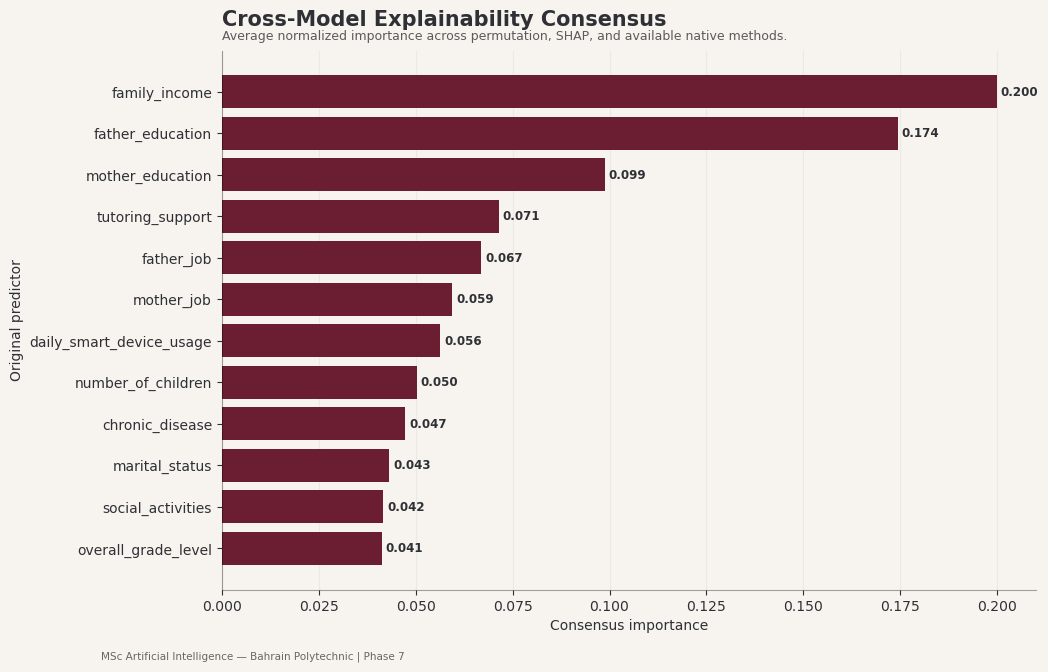

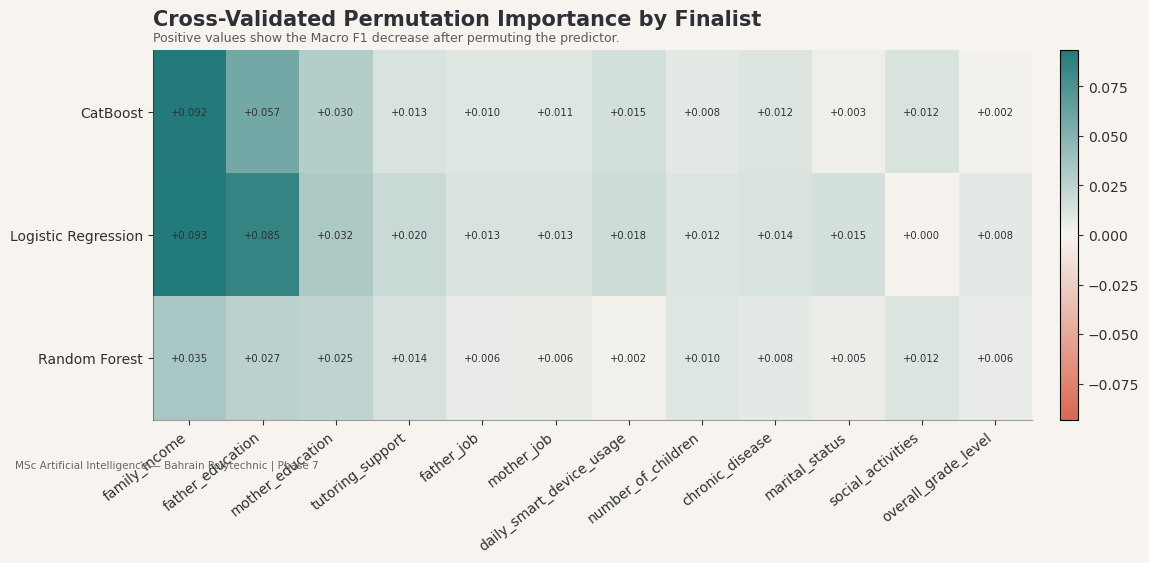

In [17]:
# Cell 7.10.1 — Visualise Consensus and Model-Specific Importance

CELL_FOLDERS = create_cell_folders(
    "07_10", "Multiple_Visualization_Explainability",
    "07_10_01", "Visualise_Consensus_and_Model_Specific_Importance"
)

top_consensus = consensus_feature_importance.head(TOP_FEATURES_TO_REPORT).sort_values(
    "consensus_importance"
)
figure, axis = plt.subplots(figsize=(10.5, 7))
bars = axis.barh(
    top_consensus["feature"], top_consensus["consensus_importance"],
    color=THEME["maroon"]
)
for bar, value in zip(bars, top_consensus["consensus_importance"]):
    axis.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
              f"{value:.3f}", va="center", fontsize=8.5, fontweight="bold")
style_axis(
    axis,
    "Cross-Model Explainability Consensus",
    "Average normalized importance across permutation, SHAP, and available native methods.",
    "x",
)
axis.set_xlabel("Consensus importance")
axis.set_ylabel("Original predictor")
save_figure(figure, CELL_FOLDERS, "07_10_01_consensus_importance")
plt.show()

permutation_heatmap = permutation_importance.pivot(
    index="model", columns="feature", values="mean_importance_drop"
).reindex(columns=consensus_feature_importance["feature"])
heatmap_columns = consensus_feature_importance.head(TOP_FEATURES_TO_REPORT)["feature"].tolist()
permutation_heatmap = permutation_heatmap[heatmap_columns]
values = permutation_heatmap.to_numpy()
max_abs = max(np.abs(values).max(), 0.001)
figure, axis = plt.subplots(figsize=(12, max(4.8, len(permutation_heatmap)*0.9)))
image = axis.imshow(
    values, aspect="auto", vmin=-max_abs, vmax=max_abs,
    cmap=LinearSegmentedColormap.from_list(
        "permutation_diverging", [THEME["coral"], THEME["warm_white"], THEME["teal"]]
    )
)
axis.set_xticks(np.arange(len(heatmap_columns)))
axis.set_xticklabels(heatmap_columns, rotation=38, ha="right")
axis.set_yticks(np.arange(len(permutation_heatmap.index)))
axis.set_yticklabels(permutation_heatmap.index)
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        axis.text(j, i, f"{values[i,j]:+.3f}", ha="center", va="center", fontsize=7.2)
style_axis(
    axis,
    "Cross-Validated Permutation Importance by Finalist",
    "Positive values show the Macro F1 decrease after permuting the predictor.",
    None,
)
figure.colorbar(image, ax=axis, fraction=0.025, pad=0.03)
save_figure(figure, CELL_FOLDERS, "07_10_01_permutation_heatmap")
plt.show()

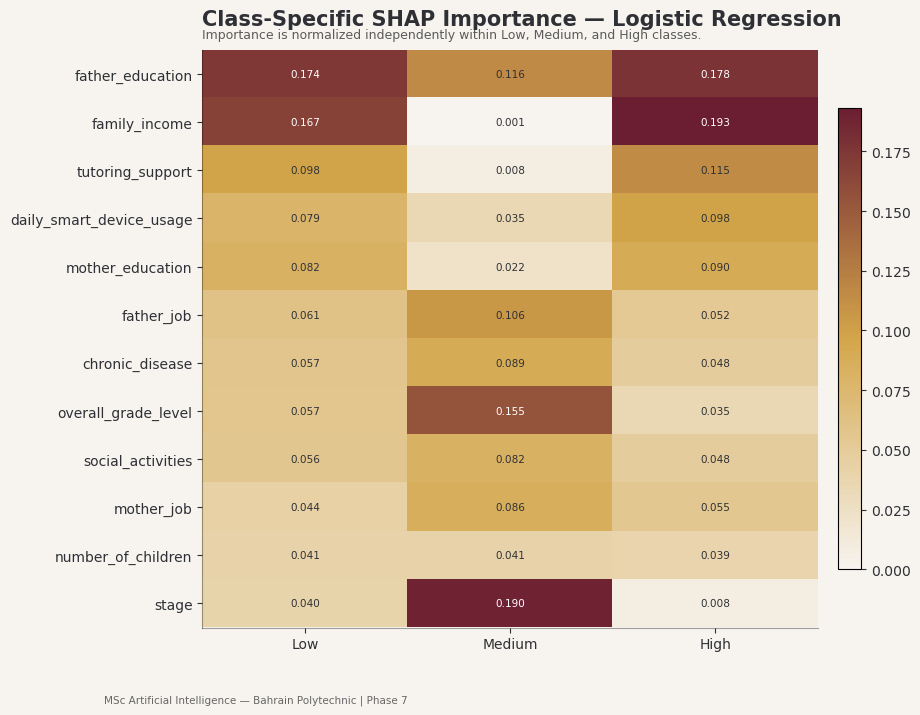

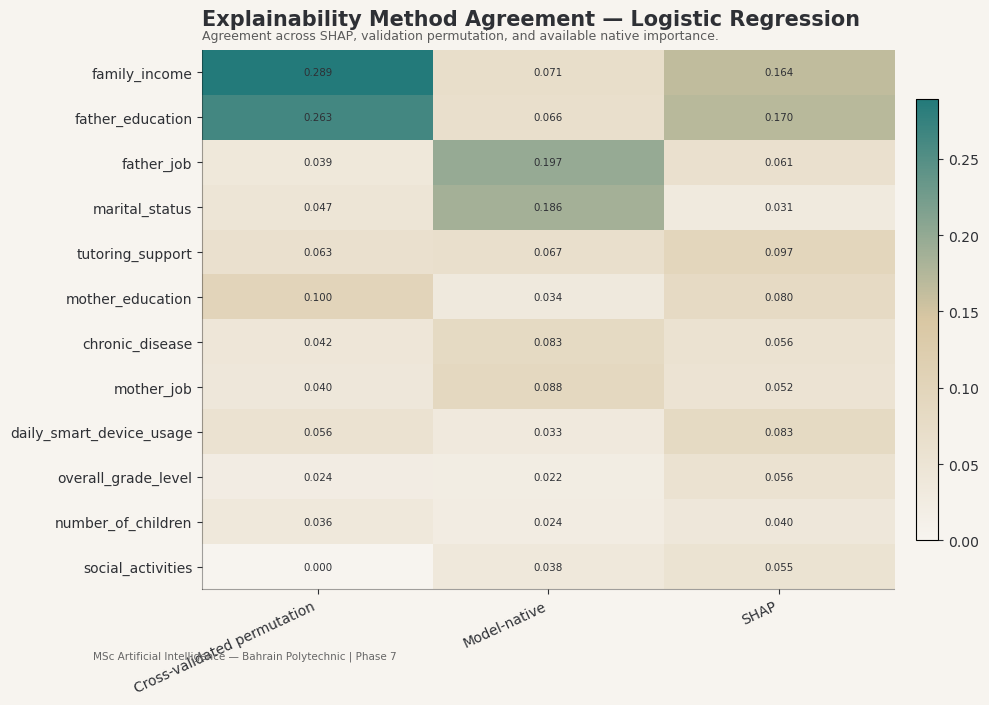

In [18]:
# Cell 7.10.2 — Visualise Class-Specific SHAP and Method Agreement

CELL_FOLDERS = create_cell_folders(
    "07_10", "Multiple_Visualization_Explainability",
    "07_10_02", "Visualise_Class_Specific_SHAP_and_Method_Agreement"
)

class_heatmap = top_model_class_importance.pivot(
    index="feature", columns="class_name", values="normalized_within_class"
).reindex(columns=TARGET_CLASSES)
class_features = (
    top_model_class_importance.groupby("feature")["mean_absolute_shap"].sum()
    .sort_values(ascending=False).head(TOP_FEATURES_TO_REPORT).index
)
class_heatmap = class_heatmap.loc[class_features]
values = class_heatmap.to_numpy()
figure, axis = plt.subplots(figsize=(8.5, 7.5))
image = axis.imshow(
    values, aspect="auto", vmin=0,
    cmap=LinearSegmentedColormap.from_list(
        "class_importance", [THEME["warm_white"], THEME["gold"], THEME["maroon"]]
    )
)
axis.set_xticks(np.arange(len(TARGET_CLASSES)))
axis.set_xticklabels(TARGET_CLASSES)
axis.set_yticks(np.arange(len(class_heatmap.index)))
axis.set_yticklabels(class_heatmap.index)
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        axis.text(j, i, f"{values[i,j]:.3f}", ha="center", va="center", fontsize=7.5,
                  color="white" if values[i,j] > values.max()*0.65 else THEME["charcoal"])
style_axis(
    axis,
    f"Class-Specific SHAP Importance — {TOP_MODEL_NAME}",
    "Importance is normalized independently within Low, Medium, and High classes.",
    None,
)
figure.colorbar(image, ax=axis, fraction=0.035, pad=0.03)
save_figure(figure, CELL_FOLDERS, "07_10_02_class_specific_shap")
plt.show()

top_model_methods = explainability_method_scores[
    explainability_method_scores["model"] == TOP_MODEL_NAME
]
method_pivot = top_model_methods.pivot(
    index="feature", columns="method", values="normalized_score"
).fillna(0)
method_features = method_pivot.mean(axis=1).sort_values(ascending=False).head(
    TOP_FEATURES_TO_REPORT
).index
method_pivot = method_pivot.loc[method_features]
values = method_pivot.to_numpy()
figure, axis = plt.subplots(figsize=(9.5, 7))
image = axis.imshow(
    values, aspect="auto", vmin=0,
    cmap=LinearSegmentedColormap.from_list(
        "agreement", [THEME["warm_white"], THEME["sand"], THEME["teal"]]
    )
)
axis.set_xticks(np.arange(len(method_pivot.columns)))
axis.set_xticklabels(method_pivot.columns, rotation=25, ha="right")
axis.set_yticks(np.arange(len(method_pivot.index)))
axis.set_yticklabels(method_pivot.index)
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        axis.text(j, i, f"{values[i,j]:.3f}", ha="center", va="center", fontsize=7.4)
style_axis(
    axis,
    f"Explainability Method Agreement — {TOP_MODEL_NAME}",
    "Agreement across SHAP, validation permutation, and available native importance.",
    None,
)
figure.colorbar(image, ax=axis, fraction=0.03, pad=0.03)
save_figure(figure, CELL_FOLDERS, "07_10_02_method_agreement")
plt.show()

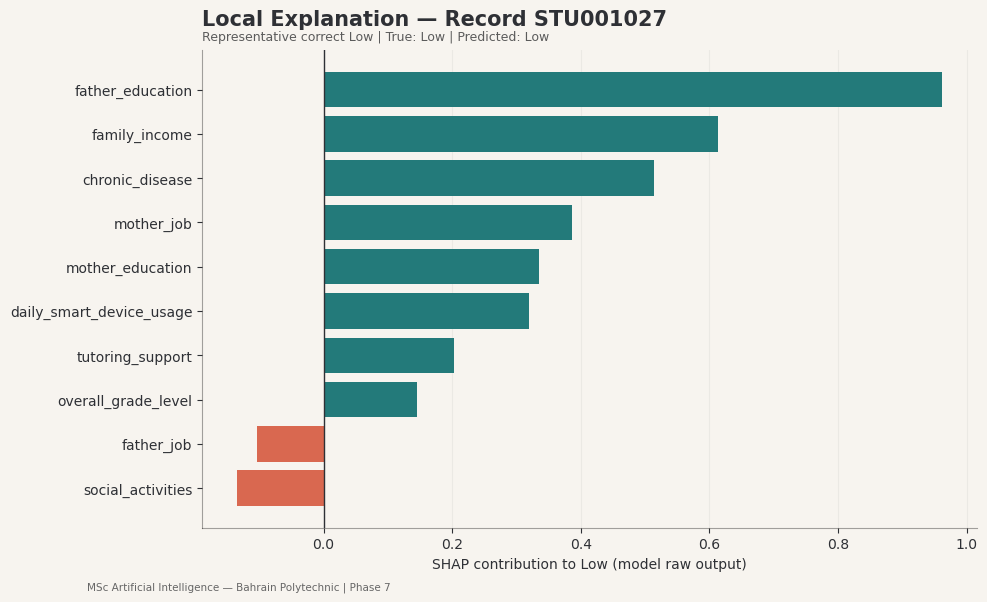

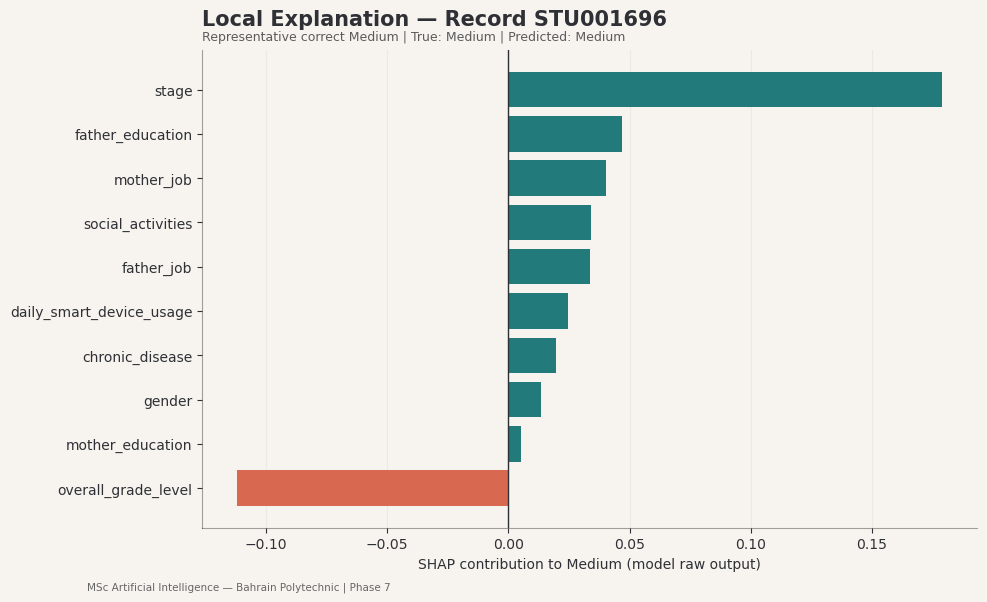

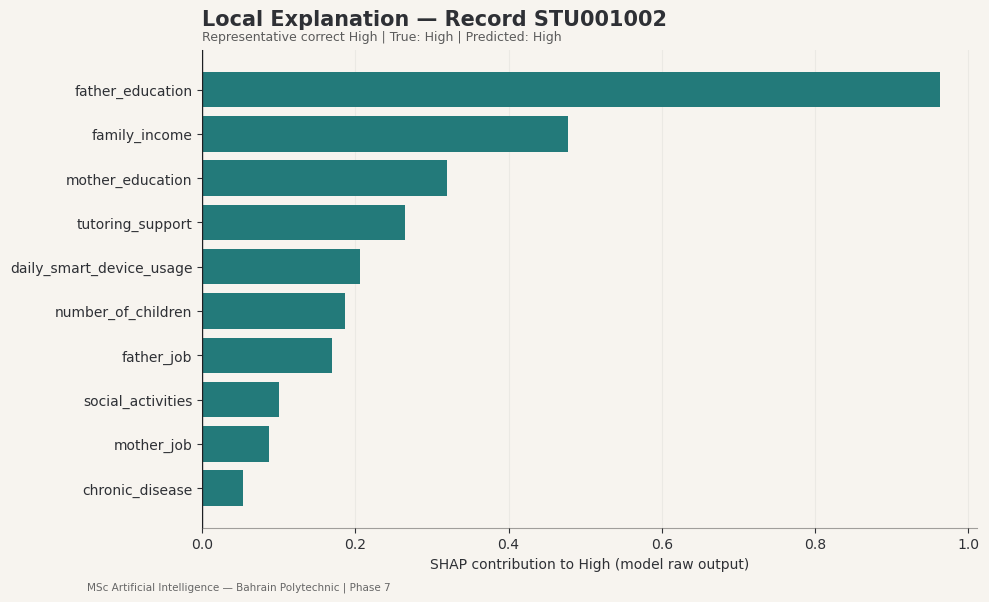

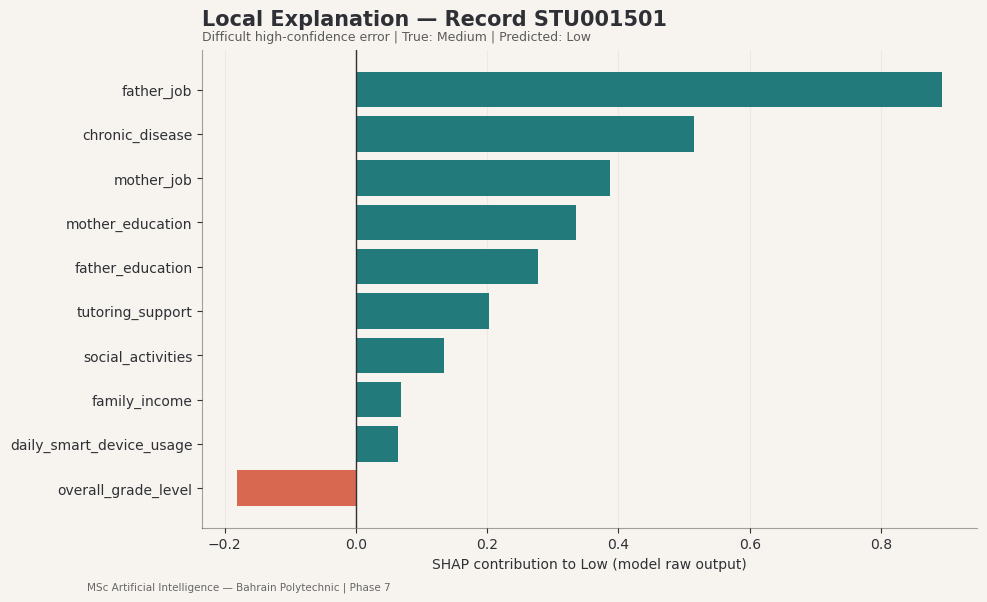

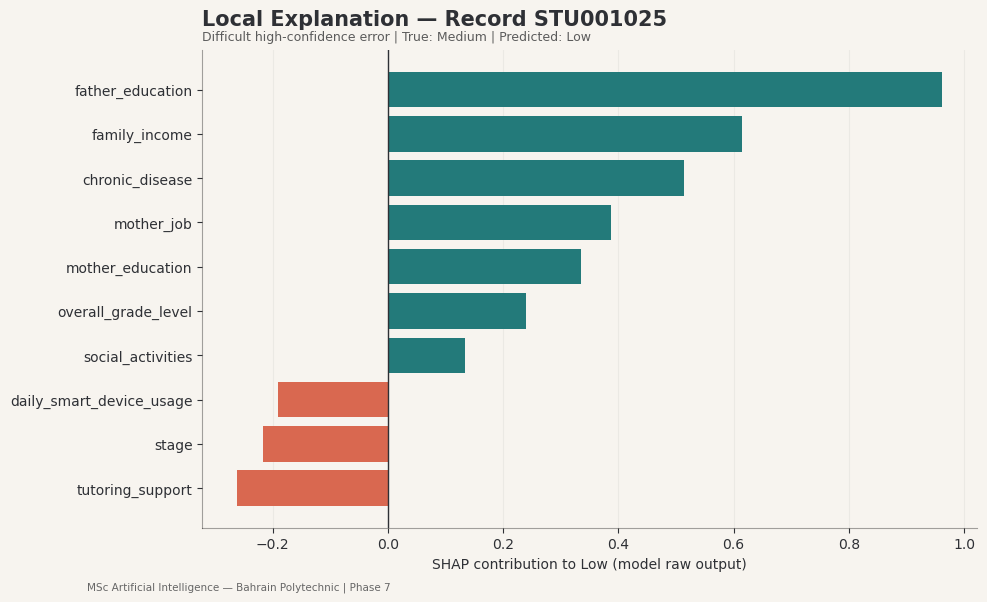

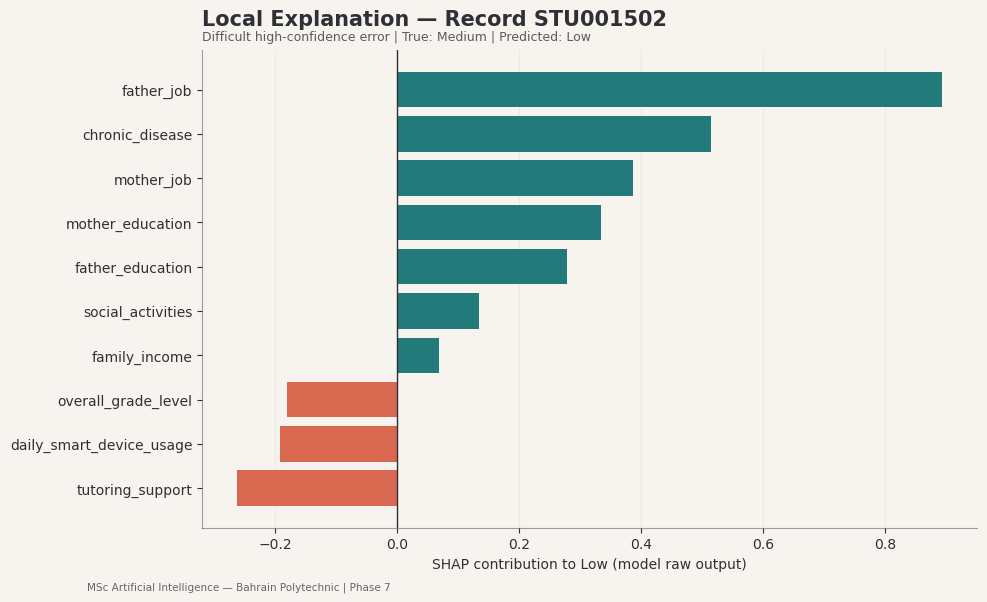

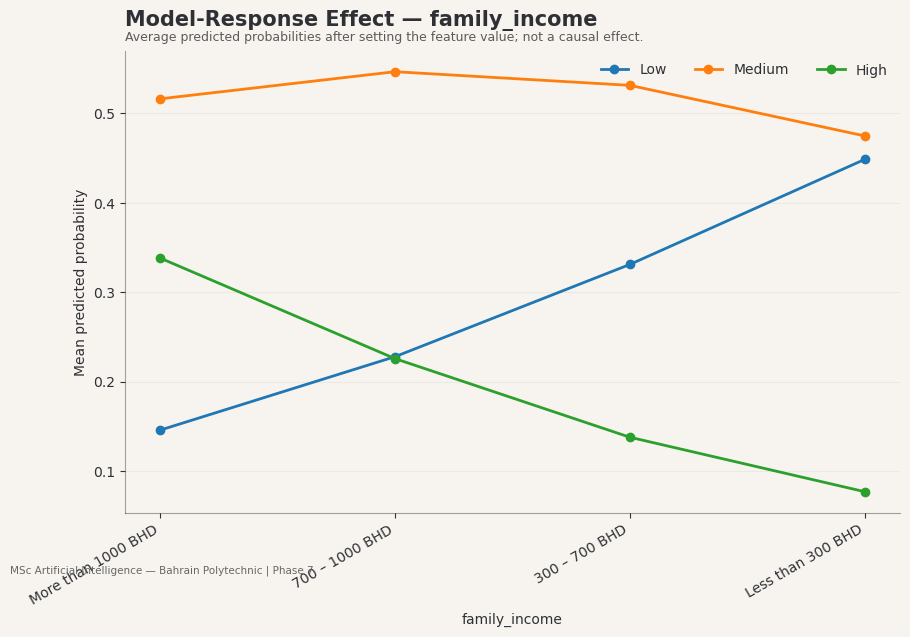

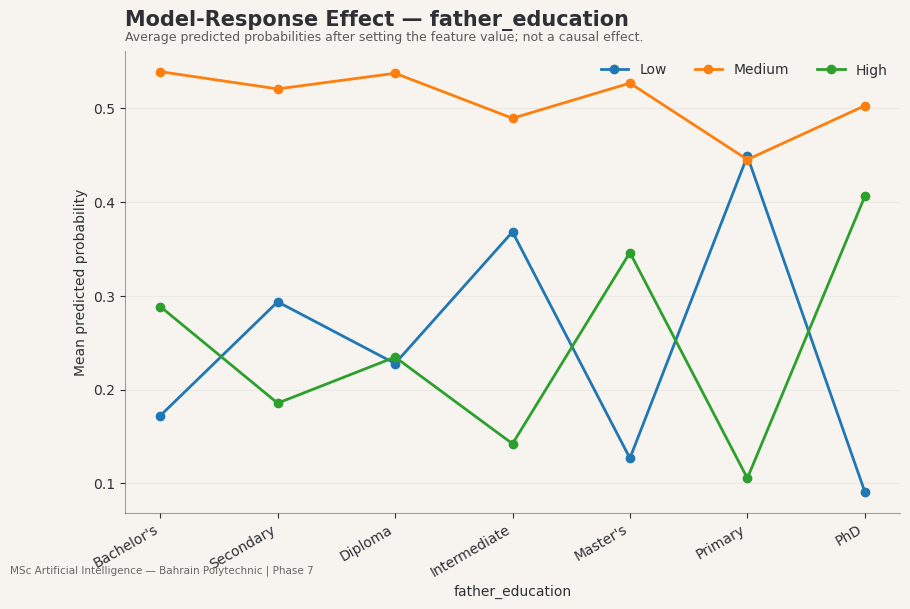

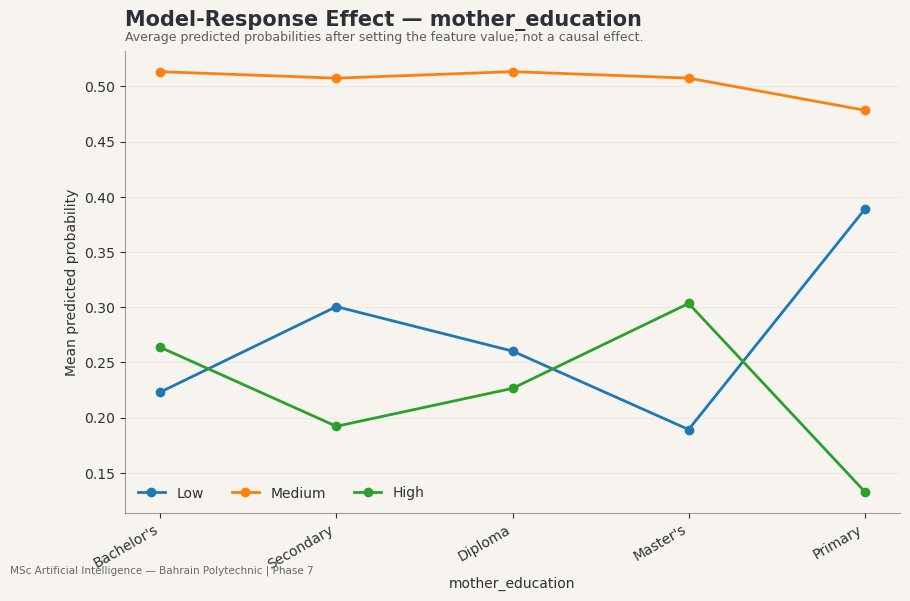

In [19]:
# Cell 7.10.3 — Visualise Local Explanations and Feature Effects

CELL_FOLDERS = create_cell_folders(
    "07_10", "Multiple_Visualization_Explainability",
    "07_10_03", "Visualise_Local_Explanations_and_Feature_Effects"
)

for record_id in local_example_selection[ID_COLUMN].head(6):
    record_data = local_explanations[
        local_explanations[ID_COLUMN] == record_id
    ].nlargest(10, "absolute_shap_contribution").sort_values(
        "signed_shap_contribution_to_predicted_class"
    )
    if record_data.empty:
        continue
    selection = local_example_selection[
        local_example_selection[ID_COLUMN] == record_id
    ].iloc[0]
    colors = [
        THEME["teal"] if value >= 0 else THEME["coral"]
        for value in record_data["signed_shap_contribution_to_predicted_class"]
    ]
    figure, axis = plt.subplots(figsize=(10, 6.2))
    axis.barh(
        record_data["feature"],
        record_data["signed_shap_contribution_to_predicted_class"],
        color=colors,
    )
    axis.axvline(0, color=THEME["charcoal"], linewidth=1)
    style_axis(
        axis,
        f"Local Explanation — Record {record_id}",
        f"{selection['example_type']} | True: {selection['true_class']} | "
        f"Predicted: {selection['predicted_class']}",
        "x",
    )
    axis.set_xlabel(f"SHAP contribution to {selection['predicted_class']} ({local_output_scale})")
    save_figure(figure, CELL_FOLDERS, f"07_10_03_local_{safe_name(record_id)}")
    plt.show()

for feature in TOP_EFFECT_FEATURES[:3]:
    plot_data = feature_effects[feature_effects["feature"] == feature].copy()
    numeric_effect = plot_data["intervention_numeric"].notna().all()
    figure, axis = plt.subplots(figsize=(10, 6))
    for class_name in TARGET_CLASSES:
        class_data = plot_data[plot_data["class_name"] == class_name]
        if numeric_effect:
            x_values = class_data["intervention_numeric"].to_numpy()
        else:
            x_values = np.arange(len(class_data))
        axis.plot(
            x_values,
            class_data["mean_predicted_probability"],
            marker="o",
            linewidth=2,
            label=class_name,
        )
    if not numeric_effect:
        labels = plot_data[plot_data["class_name"] == TARGET_CLASSES[0]][
            "intervention_value"
        ].tolist()
        axis.set_xticks(np.arange(len(labels)))
        axis.set_xticklabels(labels, rotation=30, ha="right")
    style_axis(
        axis,
        f"Model-Response Effect — {feature}",
        "Average predicted probabilities after setting the feature value; not a causal effect.",
    )
    axis.set_xlabel(feature)
    axis.set_ylabel("Mean predicted probability")
    axis.legend(ncol=3)
    save_figure(figure, CELL_FOLDERS, f"07_10_03_effect_{safe_name(feature)}")
    plt.show()

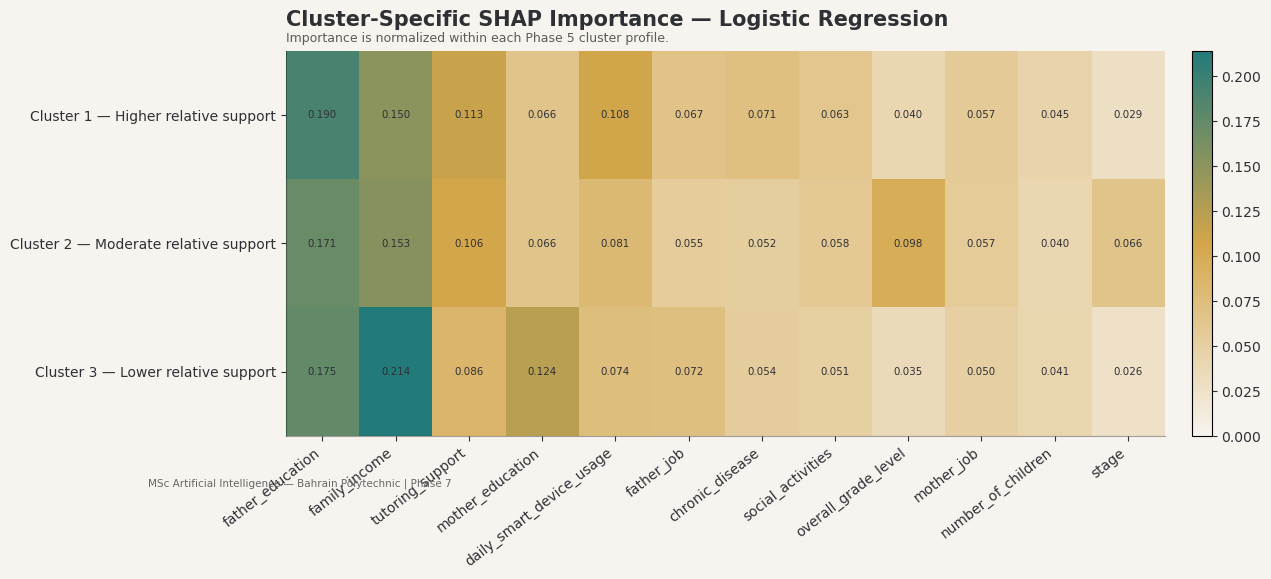

,figure_number,figure_name,relative_path,file_size_kb
0,1,07_10_01_consensus_importance,Section_07_10_Multiple_Visualization_Explainab...,249.56
1,2,07_10_01_permutation_heatmap,Section_07_10_Multiple_Visualization_Explainab...,416.63
2,3,07_10_02_class_specific_shap,Section_07_10_Multiple_Visualization_Explainab...,310.14
3,4,07_10_02_method_agreement,Section_07_10_Multiple_Visualization_Explainab...,347.20
4,5,07_10_03_effect_family_income,Section_07_10_Multiple_Visualization_Explainab...,277.58
5,6,07_10_03_effect_father_education,Section_07_10_Multiple_Visualization_Explainab...,353.74
6,7,07_10_03_effect_mother_education,Section_07_10_Multiple_Visualization_Explainab...,276.92
7,8,07_10_03_local_STU001002,Section_07_10_Multiple_Visualization_Explainab...,176.63
8,9,07_10_03_local_STU001025,Section_07_10_Multiple_Visualization_Explainab...,177.73
9,10,07_10_03_local_STU001027,Section_07_10_Multiple_Visualization_Explainab...,177.28


In [20]:
# Cell 7.10.4 — Visualise Cluster-Specific Importance and Create Figure Catalogue

CELL_FOLDERS = create_cell_folders(
    "07_10", "Multiple_Visualization_Explainability",
    "07_10_04", "Visualise_Cluster_Specific_Importance_and_Create_Figure_Catalogue"
)

if not cluster_specific_importance.empty:
    cluster_label_column = (
        "cluster_name" if "cluster_name" in cluster_specific_importance.columns else "cluster_id"
    )
    cluster_pivot = cluster_specific_importance.pivot(
        index=cluster_label_column,
        columns="feature",
        values="mean_absolute_shap",
    )
    top_cluster_features = (
        cluster_specific_importance.groupby("feature")["mean_absolute_shap"]
        .mean().sort_values(ascending=False).head(TOP_FEATURES_TO_REPORT).index
    )
    cluster_pivot = cluster_pivot[top_cluster_features]
    normalized_cluster_pivot = cluster_pivot.div(cluster_pivot.sum(axis=1), axis=0)
    values = normalized_cluster_pivot.to_numpy()
    figure, axis = plt.subplots(figsize=(12, max(5, len(normalized_cluster_pivot)*0.9)))
    image = axis.imshow(
        values, aspect="auto", vmin=0,
        cmap=LinearSegmentedColormap.from_list(
            "cluster_importance", [THEME["warm_white"], THEME["gold"], THEME["teal"]]
        )
    )
    axis.set_xticks(np.arange(len(normalized_cluster_pivot.columns)))
    axis.set_xticklabels(normalized_cluster_pivot.columns, rotation=38, ha="right")
    axis.set_yticks(np.arange(len(normalized_cluster_pivot.index)))
    axis.set_yticklabels(normalized_cluster_pivot.index)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            axis.text(j, i, f"{values[i,j]:.3f}", ha="center", va="center", fontsize=7.4)
    style_axis(
        axis,
        f"Cluster-Specific SHAP Importance — {TOP_MODEL_NAME}",
        "Importance is normalized within each Phase 5 cluster profile.",
        None,
    )
    figure.colorbar(image, ax=axis, fraction=0.025, pad=0.03)
    save_figure(figure, CELL_FOLDERS, "07_10_04_cluster_specific_importance")
    plt.show()

figure_files = sorted(PHASE_DIR.rglob("*.png"))
visualisation_catalogue = pd.DataFrame([
    {
        "figure_number": index,
        "figure_name": path.stem,
        "relative_path": str(path.relative_to(PHASE_DIR)),
        "file_size_kb": round(path.stat().st_size / 1024, 2),
    }
    for index, path in enumerate(figure_files, start=1)
])

save_dataframe(visualisation_catalogue, CELL_FOLDERS, "07_10_04_visualisation_catalogue")
display(visualisation_catalogue)

# Section 7.11 — Export Multiple Files and Phase 8 Handoff

In [21]:
# Cell 7.11.1 — Export Official Phase 7 Results

CELL_FOLDERS = create_cell_folders(
    "07_11", "Export_Multiple_Files_and_Phase_8_Handoff",
    "07_11_01", "Export_Official_Phase_7_Results"
)

OFFICIAL_PATHS = {
    "permutation_importance": DATA_DIR / "phase_07_permutation_importance.csv",
    "shap_global_importance": DATA_DIR / "phase_07_shap_global_importance.csv",
    "shap_class_importance": DATA_DIR / "phase_07_shap_class_importance.csv",
    "consensus_feature_importance": DATA_DIR / "phase_07_consensus_feature_importance.csv",
    "model_native_importance": DATA_DIR / "phase_07_model_native_importance.csv",
    "local_explanations": DATA_DIR / "phase_07_local_explanations.csv",
    "feature_effects": DATA_DIR / "phase_07_feature_effects.csv",
    "cluster_specific_importance": DATA_DIR / "phase_07_cluster_specific_importance.csv",
    "feature_group_consensus": DATA_DIR / "phase_07_feature_group_consensus.csv",
    "shap_engine_summary": DATA_DIR / "phase_07_shap_engine_summary.csv",
}

TABLES_TO_EXPORT = {
    "permutation_importance": permutation_importance,
    "shap_global_importance": shap_global_importance,
    "shap_class_importance": shap_class_importance,
    "consensus_feature_importance": consensus_feature_importance,
    "model_native_importance": model_native_importance,
    "local_explanations": local_explanations,
    "feature_effects": feature_effects,
    "cluster_specific_importance": cluster_specific_importance,
    "feature_group_consensus": feature_group_consensus,
    "shap_engine_summary": shap_engine_summary,
}

for artifact_name, output_path in OFFICIAL_PATHS.items():
    TABLES_TO_EXPORT[artifact_name].to_csv(output_path, index=False, encoding="utf-8-sig")
    shutil.copy2(output_path, CELL_FOLDERS["files"] / output_path.name)

export_summary = pd.DataFrame([
    {
        "artifact": name,
        "path": str(path),
        "records": len(TABLES_TO_EXPORT[name]),
        "file_size_kb": round(path.stat().st_size / 1024, 2),
        "sha256": sha256_file(path),
    }
    for name, path in OFFICIAL_PATHS.items()
])

save_dataframe(export_summary, CELL_FOLDERS, "07_11_01_export_summary")
display(export_summary)

,artifact,path,records,file_size_kb,sha256
0,permutation_importance,C:\Users\User\Desktop\All\data\phase_07_permut...,51,7.15,b24ec2bc565f15f2b90fdf876a18648f8ab54a5c19872d...
1,shap_global_importance,C:\Users\User\Desktop\All\data\phase_07_shap_g...,51,3.53,aa42b37b7ec622db3a5fd9c94ede06c1ad458e97e6b716...
2,shap_class_importance,C:\Users\User\Desktop\All\data\phase_07_shap_c...,153,11.61,4f92fa8bdd319ee1b53897b1f8d39fb0c5e2f396c7e581...
3,consensus_feature_importance,C:\Users\User\Desktop\All\data\phase_07_consen...,17,2.14,a0e6ef86c1c469bec5b073e7ad13c53f403e729c99be63...
4,model_native_importance,C:\Users\User\Desktop\All\data\phase_07_model_...,51,3.81,ce9b9dbea122eb02fce93167a1c48e6f0ea23c91336a13...
5,local_explanations,C:\Users\User\Desktop\All\data\phase_07_local_...,102,17.10,e71f42b37179638daba8e4a566ed87f30e296e56d41b81...
6,feature_effects,C:\Users\User\Desktop\All\data\phase_07_featur...,66,12.29,f2d850e87bf2d3bf5f4091a523ad3281864de60cf8213e...
7,cluster_specific_importance,C:\Users\User\Desktop\All\data\phase_07_cluste...,51,4.25,061919eb1321dd99c09f335d3681a673948dd01352543e...
8,feature_group_consensus,C:\Users\User\Desktop\All\data\phase_07_featur...,5,0.38,683bfe3cd06a70551114136dad2335b6016612a83349db...
9,shap_engine_summary,C:\Users\User\Desktop\All\data\phase_07_shap_e...,3,0.84,dac54a6d9425592b09991f1ce5754c15a0fb53fbcfad2d...


In [22]:
# Cell 7.11.2 — Create Consolidated CSV Report Directory

CELL_FOLDERS = create_cell_folders(
    "07_11", "Export_Multiple_Files_and_Phase_8_Handoff",
    "07_11_02", "Create_Consolidated_CSV_Report_Directory"
)

CONSOLIDATED_REPORT_DIR = CELL_FOLDERS["files"] / "phase_07_consolidated_reports"
CONSOLIDATED_REPORT_DIR.mkdir(parents=True, exist_ok=True)

report_tables = {
    "project_configuration": pd.DataFrame([project_configuration]),
    "library_versions": library_versions,
    "lineage_checks": lineage_checks,
    "finalist_registry": finalist_registry,
    "transformed_feature_map": transformed_feature_map,
    "permutation_importance": permutation_importance,
    "shap_engine_summary": shap_engine_summary,
    "shap_global_importance": shap_global_importance,
    "shap_class_importance": shap_class_importance,
    "model_native_importance": model_native_importance,
    "model_class_coefficients": model_class_coefficients,
    "explainability_method_scores": explainability_method_scores,
    "consensus_feature_importance": consensus_feature_importance,
    "feature_group_consensus": feature_group_consensus,
    "cluster_specific_importance": cluster_specific_importance,
    "local_example_selection": local_example_selection,
    "local_explanations": local_explanations,
    "feature_effects": feature_effects,
    "visualisation_catalogue": visualisation_catalogue,
    "export_summary": export_summary,
}

for report_name, dataframe in report_tables.items():
    dataframe.to_csv(
        CONSOLIDATED_REPORT_DIR / f"{report_name}.csv",
        index=False,
        encoding="utf-8-sig",
    )

print("Consolidated CSV reports:", CONSOLIDATED_REPORT_DIR)

Consolidated CSV reports: C:\Users\User\Desktop\All\outputs\Phase_07_Model_Explainability_and_Interpretation\Section_07_11_Export_Multiple_Files_and_Phase_8_Handoff\Cell_07_11_02_Create_Consolidated_CSV_Report_Directory\files\phase_07_consolidated_reports


In [23]:
# Cell 7.11.3 — Run Final Quality Checks and Create Phase 8 Handoff

CELL_FOLDERS = create_cell_folders(
    "07_11", "Export_Multiple_Files_and_Phase_8_Handoff",
    "07_11_03", "Run_Final_Quality_Checks_and_Create_Phase_8_Handoff"
)

quality_checks = []


def add_quality_check(name, passed, details):
    quality_checks.append({
        "quality_check": name,
        "passed": bool(passed),
        "details": str(details),
    })


finalist_model_names = set(finalist_registry["model"])
add_quality_check(
    "Every Phase 6 finalist has permutation importance",
    set(permutation_importance["model"]) == finalist_model_names,
    sorted(permutation_importance["model"].unique()),
)
add_quality_check(
    "Every Phase 6 finalist has SHAP global importance",
    set(shap_global_importance["model"]) == finalist_model_names,
    sorted(shap_global_importance["model"].unique()),
)
add_quality_check(
    "Every finalist has all original predictors in permutation importance",
    permutation_importance.groupby("model")["feature"].nunique().eq(len(PREDICTOR_COLUMNS)).all(),
    len(PREDICTOR_COLUMNS),
)
add_quality_check(
    "All SHAP importance values are finite",
    np.isfinite(shap_global_importance["mean_absolute_shap"]).all(),
    len(shap_global_importance),
)
add_quality_check(
    "Local explanations are traceable to training records",
    set(local_explanations[ID_COLUMN]).issubset(set(record_ids)),
    local_explanations[ID_COLUMN].nunique(),
)
add_quality_check(
    "Target and identifiers are excluded from explanation predictors",
    not {TARGET_COLUMN, ID_COLUMN, GROUP_COLUMN}.intersection(PREDICTOR_COLUMNS),
    [TARGET_COLUMN, ID_COLUMN, GROUP_COLUMN],
)
add_quality_check(
    "Holdout test was not loaded",
    True,
    phase_3_manifest.get("untouched_holdout_test_for_phase_8"),
)

phase_7_quality_checks = pd.DataFrame(quality_checks)
save_dataframe(phase_7_quality_checks, CELL_FOLDERS, "07_11_03_phase_7_quality_checks")
save_json_report(quality_checks, CELL_FOLDERS, "07_11_03_phase_7_quality_checks")

if not phase_7_quality_checks["passed"].all():
    failed = phase_7_quality_checks.loc[
        ~phase_7_quality_checks["passed"], "quality_check"
    ].tolist()
    raise AssertionError("Phase 7 quality checks failed: " + "; ".join(failed))

top_consensus_features = consensus_feature_importance.head(10)[
    ["consensus_rank", "feature", "consensus_importance", "feature_group"]
].to_dict(orient="records")

phase_8_handoff = {
    "completed_phase": "Phase 7 — Model Explainability and Interpretation",
    "next_phase": "Phase 8 — Final Model and Prediction Pipeline",
    "training_dataset": str(TRAINING_DATA_PATH),
    "cv_assignment": str(CV_ASSIGNMENT_PATH),
    "phase_6_finalists": finalist_rows,
    "phase_6_primary_candidate": {
        "model": TOP_MODEL_NAME,
        "stage": TOP_MODEL_STAGE,
        "model_path": finalist_registry.iloc[0]["model_path"],
    },
    "permutation_importance": str(OFFICIAL_PATHS["permutation_importance"]),
    "shap_global_importance": str(OFFICIAL_PATHS["shap_global_importance"]),
    "shap_class_importance": str(OFFICIAL_PATHS["shap_class_importance"]),
    "consensus_feature_importance": str(OFFICIAL_PATHS["consensus_feature_importance"]),
    "local_explanations": str(OFFICIAL_PATHS["local_explanations"]),
    "feature_effects": str(OFFICIAL_PATHS["feature_effects"]),
    "cluster_specific_importance": str(OFFICIAL_PATHS["cluster_specific_importance"]),
    "top_consensus_features": top_consensus_features,
    "target_mapping": TARGET_MAPPING,
    "target_classes": TARGET_CLASSES,
    "holdout_test_used": False,
    "holdout_test_path_recorded_but_not_loaded": phase_3_manifest.get(
        "untouched_holdout_test_for_phase_8"
    ),
    "final_holdout_evaluation_phase": 8,
    "quality_checks_passed": True,
    "generated_at": datetime.now().isoformat(),
}

PHASE_8_HANDOFF_PATH = save_json_report(
    phase_8_handoff, CELL_FOLDERS, "phase_07_handoff_manifest_for_phase_08"
)
with (PHASE_DIR / "phase_07_handoff_manifest_for_phase_08.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(phase_8_handoff, file, ensure_ascii=False, indent=2)

summary_text = f"""
PHASE 7 COMPLETION SUMMARY
{'=' * 76}

Training records explained: {len(training_data):,}
Finalist models explained: {len(finalist_registry)}
Top Phase 6 candidate: {TOP_MODEL_NAME} ({TOP_MODEL_STAGE})
Cross-validation folds used for permutation importance: {len(CV_SPLITS)}
Holdout test used: False

Top consensus predictors:
{chr(10).join(
    f"- {int(row.consensus_rank)}. {row.feature}: {row.consensus_importance:.4f}"
    for row in consensus_feature_importance.head(10).itertuples()
)}

Interpretation policy:
- Permutation importance is validation-based.
- SHAP explains full-training finalist models and is not a performance estimate.
- Feature effects are non-causal model-response diagnostics.
""".strip()

summary_path = CELL_FOLDERS["reports"] / "07_11_03_phase_7_summary.txt"
summary_path.write_text(summary_text, encoding="utf-8")

display(phase_7_quality_checks)
print(summary_text)
print("Phase 8 handoff:", PHASE_8_HANDOFF_PATH)

,quality_check,passed,details
0,Every Phase 6 finalist has permutation importance,True,"['CatBoost', 'Logistic Regression', 'Random Fo..."
1,Every Phase 6 finalist has SHAP global importance,True,"['CatBoost', 'Logistic Regression', 'Random Fo..."
2,Every finalist has all original predictors in ...,True,17
3,All SHAP importance values are finite,True,51
4,Local explanations are traceable to training r...,True,6
5,Target and identifiers are excluded from expla...,True,"['academic_performance_class', 'student_record..."
6,Holdout test was not loaded,True,C:\Users\User\Desktop\All\data\phase_03_untouc...


PHASE 7 COMPLETION SUMMARY

Training records explained: 2,006
Finalist models explained: 3
Top Phase 6 candidate: Logistic Regression (Baseline)
Cross-validation folds used for permutation importance: 5
Holdout test used: False

Top consensus predictors:
- 1. family_income: 0.1999
- 2. father_education: 0.1744
- 3. mother_education: 0.0987
- 4. tutoring_support: 0.0714
- 5. father_job: 0.0669
- 6. mother_job: 0.0595
- 7. daily_smart_device_usage: 0.0564
- 8. number_of_children: 0.0502
- 9. chronic_disease: 0.0473
- 10. marital_status: 0.0432

Interpretation policy:
- Permutation importance is validation-based.
- SHAP explains full-training finalist models and is not a performance estimate.
- Feature effects are non-causal model-response diagnostics.
Phase 8 handoff: C:\Users\User\Desktop\All\outputs\Phase_07_Model_Explainability_and_Interpretation\Section_07_11_Export_Multiple_Files_and_Phase_8_Handoff\Cell_07_11_03_Run_Final_Quality_Checks_and_Create_Phase_8_Handoff\reports\phase_07_h

In [24]:
# Cell 7.11.4 — Create the Complete Phase 7 ZIP Archive

CELL_FOLDERS = create_cell_folders(
    "07_11", "Export_Multiple_Files_and_Phase_8_Handoff",
    "07_11_04", "Create_the_Complete_Phase_7_ZIP_Archive"
)

ZIP_PATH = CELL_FOLDERS["files"] / "07_11_04_phase_7_complete_export.zip"
with zipfile.ZipFile(ZIP_PATH, mode="w", compression=zipfile.ZIP_DEFLATED) as zip_file:
    for file_path in sorted(PHASE_DIR.rglob("*")):
        if not file_path.is_file() or file_path == ZIP_PATH:
            continue
        zip_file.write(file_path, file_path.relative_to(PHASE_DIR))

print("Complete ZIP:", ZIP_PATH)

Complete ZIP: C:\Users\User\Desktop\All\outputs\Phase_07_Model_Explainability_and_Interpretation\Section_07_11_Export_Multiple_Files_and_Phase_8_Handoff\Cell_07_11_04_Create_the_Complete_Phase_7_ZIP_Archive\files\07_11_04_phase_7_complete_export.zip


# Phase 7 Completed

Phase 7 explains the finalist models through complementary methods:

```text
Cross-validated permutation importance
+ SHAP global importance
+ SHAP class-specific importance
+ model-native importance
+ local explanations
+ feature-response effects
+ cluster-specific interpretation
```

The untouched holdout test set remains reserved for Phase 8.